# Activity Classification with Decision Trees - Complete Analysis

## Overview
This notebook performs comprehensive activity classification using IMU data from Nicla Vision. It includes:
- **Visual EDA** for all 12 activities
- **Cross-Validation Strategies**: KFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit, TimeSeriesSplit
- **Split Criteria Comparison**: Gini vs Entropy
- **Hyperparameter Tuning** with Optuna (not GridSearch)
- **Feature Importance** analysis
- **Model Export**: m2cgen (Python), micromlgen (C/C++), text tree
- **Memory-Accuracy Trade-off** visualization
- **Class Imbalance Handling** with class_weight='balanced'
- **Model Comparison**: Decision Tree, Random Forest, Logistic Regression

In [4]:
import os
import numpy as np
import pandas as pd
import re
import pickle
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, 
    ShuffleSplit, StratifiedShuffleSplit, TimeSeriesSplit, 
    cross_val_score
)
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, 
    f1_score, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

sns.set(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✓ Libraries imported successfully.")
print("\n📊 This notebook covers:")
print("  • Visual EDA for 12 activities")
print("  • Cross-Validation: KFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit, TimeSeriesSplit")
print("  • Gini vs Entropy comparison")
print("  • Optuna hyperparameter tuning")
print("  • Feature Importance plots")
print("  • Memory-Accuracy trade-off analysis")
print("  • Model export: m2cgen, micromlgen, text tree")

✓ Libraries imported successfully.

📊 This notebook covers:
  • Visual EDA for 12 activities
  • Cross-Validation: KFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit, TimeSeriesSplit
  • Gini vs Entropy comparison
  • Optuna hyperparameter tuning
  • Feature Importance plots
  • Memory-Accuracy trade-off analysis
  • Model export: m2cgen, micromlgen, text tree


In [5]:
# Helper Functions for parameters

def calculate_skew_kurt_manual(x):
    n = len(x)
    if n == 0:
        return 0.0, 0.0
    mu = np.mean(x)
    m2 = np.mean((x - mu)**2)
    m3 = np.mean((x - mu)**3)
    m4 = np.mean((x - mu)**4)
    
    if m2 == 0:
        return 0.0, 0.0
    
    skew = m3 / (m2**(3/2))
    kurt = m4 / (m2**2)
    return skew, kurt

def calculate_entropy(x, num_bins=5):
    hist, _ = np.histogram(x, bins=num_bins)
    hist = hist.astype(float)
    hist /= hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

def calculate_dominant_freq_fft(x, num_bins=5):
    fft_vals = np.abs(np.fft.rfft(x))
    limited_fft = fft_vals[:num_bins]
    if len(limited_fft) == 0:
        return 0.0
    return np.argmax(limited_fft)

def calculate_spectral_entropy(x, num_bins=5):
    fft_vals = np.abs(np.fft.rfft(x))
    power_spectrum = fft_vals[:num_bins]**2
    if power_spectrum.sum() == 0:
        return 0.0
    prob_spectrum = power_spectrum / power_spectrum.sum()
    prob_spectrum = prob_spectrum[prob_spectrum > 0]
    return -np.sum(prob_spectrum * np.log2(prob_spectrum))

def extract_features_from_channel(x):
    features = []
    n = len(x)
    
    mean_x = np.mean(x)
    std_x = np.std(x, ddof=1)
    min_x = np.min(x)
    max_x = np.max(x)
    range_x = max_x - min_x
    var_x = np.var(x, ddof=1)
    features.extend([mean_x, std_x, min_x, max_x, range_x, var_x])
    
    skew_x, kurt_x = calculate_skew_kurt_manual(x)
    energy_x = np.sum(x**2)
    entropy_x = calculate_entropy(x, num_bins=5)
    features.extend([skew_x, kurt_x, energy_x, entropy_x])
    
    rms_x = np.sqrt(np.mean(x**2))
    zcr_x = np.sum(np.diff(np.sign(x)) != 0) / (len(x) - 1) if len(x) > 1 else 0
    mad_x = np.mean(np.abs(x - mean_x))
    median_x = np.median(x)
    iqr_x = np.percentile(x, 75) - np.percentile(x, 25)
    autocorr_x = np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 1 else 0
    features.extend([rms_x, zcr_x, mad_x, median_x, iqr_x, autocorr_x])
    
    wl_x = np.sum(np.abs(np.diff(x)))
    dom_freq_x = calculate_dominant_freq_fft(x, num_bins=5)
    spec_ent_x = calculate_spectral_entropy(x, num_bins=5)
    std_jerk_x = np.std(np.diff(x)) if len(x) > 1 else 0
    features.extend([wl_x, dom_freq_x, spec_ent_x, std_jerk_x])
    
    return features

def extract_features_window(window_data):
    all_features = []
    for col_idx in range(window_data.shape[1]):
        channel_data = window_data[:, col_idx]
        channel_features = extract_features_from_channel(channel_data)
        all_features.extend(channel_features)
    
    last_sample_raw = window_data[-1, :]
    all_features.extend(last_sample_raw)
    
    return np.array(all_features)

In [6]:
DATA_DIR = './imu_data/'
data_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"Found {len(data_files)} data files in '{DATA_DIR}'.")

label_map = {
    'sitting': 0,
    'standing': 1,
    'walking': 2,
    'brisk_walking': 3,
    'jogging': 4,
    'cycling': 5,
    'stair_up': 6,
    'stair_down': 7,
    'sit_stand_sit': 8,
    'phone_interaction': 9,
    'eating_with_spoon': 10,
    'pick_and_place': 11
}

reverse_label_map = {v: k for k, v in label_map.items()}

all_features = []
all_labels = []

for file in data_files:
    filepath = os.path.join(DATA_DIR, file)
    try:
        df = pd.read_csv(filepath)
        
        # First, try to get activity from the 'activity' column
        activity_name = None
        if 'activity' in df.columns:
            activity_col_val = df['activity'].iloc[0].strip().lower()
            # Remove segment suffix like "_seg1", "_seg2" from the activity column value
            activity_col_val = re.sub(r'_seg\d+', '', activity_col_val)
            if activity_col_val in label_map:
                activity_name = activity_col_val
        
        # If not found in column, try to parse from filename
        if activity_name is None:
            base_name = os.path.splitext(file)[0]
            # Remove segment suffix and timestamp from filename
            base_name = re.sub(r'_seg\d+', '', base_name)
            base_name = re.sub(r'_\d{8}_\d{6}$', '', base_name)  # Remove timestamp
            
            # Try to match activity from filename
            parts = base_name.split('_')
            for i in range(len(parts), 0, -1):
                candidate = '_'.join(parts[:i])
                if candidate in label_map:
                    activity_name = candidate
                    break
        
        if activity_name is None:
            print(f"Warning: Unknown activity for file '{file}' -> skipping")
            continue
        
        label = label_map[activity_name]
        print(f"Processing '{file}' -> Activity: '{activity_name}' (label={label})")

        window_size = 20
        overlap = 0.5
        step = int(window_size * (1 - overlap))

        imu_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        imu_cols = [col for col in imu_cols if col in df.columns]
        if len(imu_cols) != 6:
            print(f"Error: Missing IMU columns in {file}. Found: {imu_cols} -> skipping")
            continue
        raw_imu_data = df[imu_cols].values

        windows_extracted = 0
        for start in range(0, len(raw_imu_data) - window_size + 1, step):
            win = raw_imu_data[start:start+window_size]
            window_features = extract_features_window(win)
            all_features.append(window_features)
            all_labels.append(label)
            windows_extracted += 1
        
        print(f"  -> Extracted {windows_extracted} windows from {len(raw_imu_data)} samples")
            
    except Exception as e:
        print(f"Error processing file {file}: {e}")

print(f"\n{'='*60}")
print(f"Total windows extracted: {len(all_features)}")

X = np.array(all_features)
y = np.array(all_labels)

if X.size == 0:
    raise ValueError("No valid data was loaded. Check DATA_DIR and file formats.")

print(f"Final feature matrix shape (X): {X.shape}")
print(f"Final label vector shape (y): {y.shape}")
print(f"Unique labels found: {sorted(np.unique(y))}")
label_counts = dict(zip(*np.unique(y, return_counts=True)))
print(f"\nLabel distribution:")
for label_id in sorted(label_counts.keys()):
    activity = reverse_label_map.get(label_id, f'UNKNOWN_{label_id}')
    count = label_counts[label_id]
    print(f"  {label_id}: {activity:20s} -> {count:5d} windows")

Found 15 data files in './imu_data/'.
Processing 'brisk_walking_20260127_010444.csv' -> Activity: 'brisk_walking' (label=3)
  -> Extracted 1789 windows from 17907 samples
Processing 'cycling_20260127_013002.csv' -> Activity: 'cycling' (label=5)
  -> Extracted 1791 windows from 17922 samples
Processing 'eating_with_spoon_20260127_001451.csv' -> Activity: 'eating_with_spoon' (label=10)
  -> Extracted 1795 windows from 17962 samples
Processing 'jogging_20260127_011220.csv' -> Activity: 'jogging' (label=4)
  -> Extracted 1785 windows from 17863 samples
Processing 'phone_interaction_20260127_015207.csv' -> Activity: 'phone_interaction' (label=9)
  -> Extracted 1797 windows from 17986 samples
Processing 'pick_and_place_20260127_000926.csv' -> Activity: 'pick_and_place' (label=11)
  -> Extracted 1795 windows from 17961 samples
Processing 'sitting_seg1_20260127_000349.csv' -> Activity: 'sitting' (label=0)
  -> Extracted 1794 windows from 17952 samples
Processing 'sitting_seg2_20260126_235810.c

## Visual EDA for All 12 Activities

This section provides comprehensive exploratory data analysis including:
- Time series plots for each activity
- Distribution plots (KDE) for accelerometer and gyroscope axes
- Boxplots showing spread and outliers
- Correlation heatmaps
- Class distribution visualization

In [7]:
# Visual EDA - Load all raw data for visualization
print("=" * 60)
print("VISUAL EDA FOR ALL 12 ACTIVITIES")
print("=" * 60)

# Load all CSV files for EDA
eda_dfs = {}
for file in data_files:
    filepath = os.path.join(DATA_DIR, file)
    try:
        df_eda = pd.read_csv(filepath)
        
        # Get activity name
        activity_name = None
        if 'activity' in df_eda.columns:
            activity_col_val = df_eda['activity'].iloc[0].strip().lower()
            activity_col_val = re.sub(r'_seg\d+', '', activity_col_val)
            if activity_col_val in label_map:
                activity_name = activity_col_val
        
        if activity_name is None:
            base_name = os.path.splitext(file)[0]
            base_name = re.sub(r'_seg\d+', '', base_name)
            base_name = re.sub(r'_\d{8}_\d{6}$', '', base_name)
            parts = base_name.split('_')
            for i in range(len(parts), 0, -1):
                candidate = '_'.join(parts[:i])
                if candidate in label_map:
                    activity_name = candidate
                    break
        
        if activity_name:
            if activity_name not in eda_dfs:
                eda_dfs[activity_name] = []
            eda_dfs[activity_name].append(df_eda)
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Combine segments for each activity
combined_eda = {}
for activity, dfs in eda_dfs.items():
    combined_eda[activity] = pd.concat(dfs, ignore_index=True)

print(f"\n✓ Loaded data for {len(combined_eda)} activities:")
for act, df in combined_eda.items():
    print(f"  • {act}: {len(df)} samples")

VISUAL EDA FOR ALL 12 ACTIVITIES

✓ Loaded data for 12 activities:
  • brisk_walking: 17907 samples
  • cycling: 17922 samples
  • eating_with_spoon: 17962 samples
  • jogging: 17863 samples
  • phone_interaction: 17986 samples
  • pick_and_place: 17961 samples
  • sitting: 35914 samples
  • sit_stand_sit: 17944 samples
  • stair_down: 17947 samples
  • stair_up: 17218 samples
  • standing: 53869 samples
  • walking: 17909 samples


📊 Class Distribution (Handling Imbalance)
--------------------------------------------------


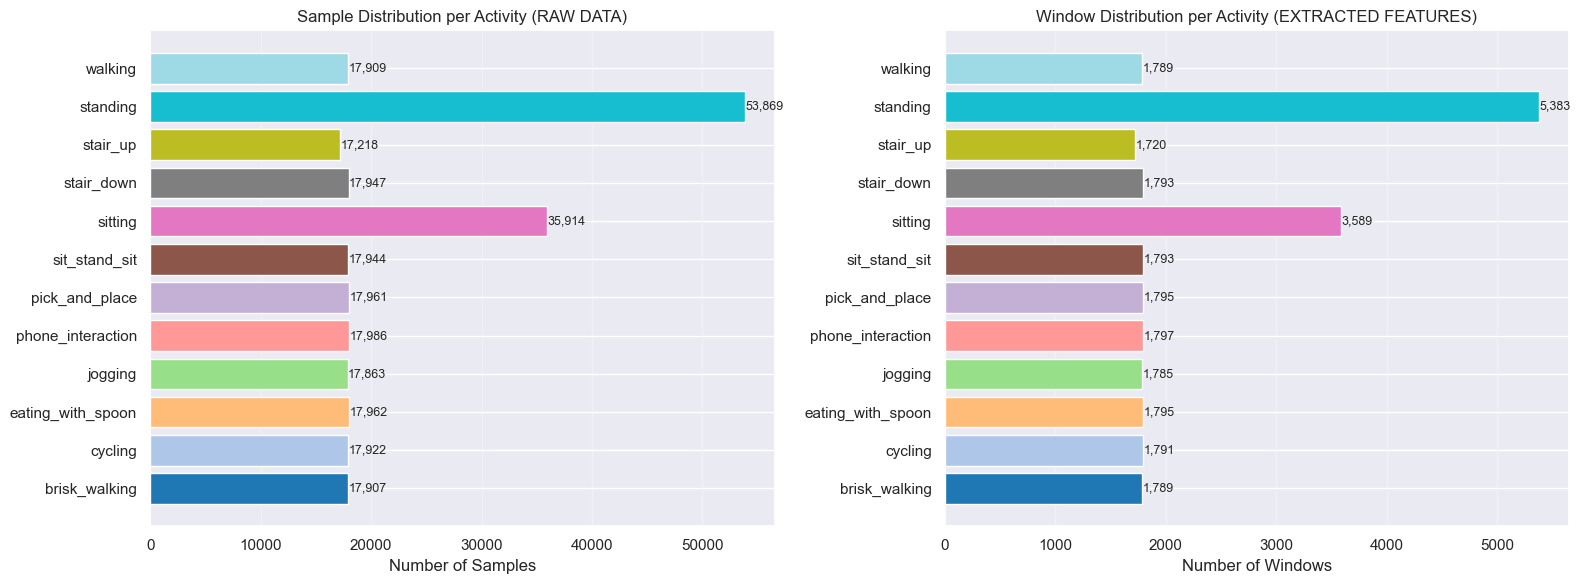


⚠️ Class Imbalance Ratio: 3.13x (max/min)
   Max class: standing (5383 windows)
   Min class: stair_up (1720 windows)

💡 Will use class_weight='balanced' to handle imbalance


In [8]:
# Class Distribution Visualization
print("📊 Class Distribution (Handling Imbalance)")
print("-" * 50)

# Create combined dataframe with activity labels
all_raw_data = []
for activity, df in combined_eda.items():
    df_copy = df.copy()
    df_copy['activity'] = activity
    all_raw_data.append(df_copy)

raw_df = pd.concat(all_raw_data, ignore_index=True)

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample counts per activity
activity_counts = raw_df['activity'].value_counts().sort_index()
colors = plt.cm.tab20(np.linspace(0, 1, len(activity_counts)))

ax1 = axes[0]
bars = ax1.barh(activity_counts.index, activity_counts.values, color=colors)
ax1.set_xlabel('Number of Samples')
ax1.set_title('Sample Distribution per Activity (RAW DATA)')
ax1.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, activity_counts.values)):
    ax1.text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# Window counts (from extracted features)
window_counts = pd.Series(y).map(reverse_label_map).value_counts().sort_index()
ax2 = axes[1]
bars2 = ax2.barh(window_counts.index, window_counts.values, color=colors)
ax2.set_xlabel('Number of Windows')
ax2.set_title('Window Distribution per Activity (EXTRACTED FEATURES)')
ax2.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars2, window_counts.values)):
    ax2.text(val + 5, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print imbalance ratio
max_count = window_counts.max()
min_count = window_counts.min()
print(f"\n⚠️ Class Imbalance Ratio: {max_count/min_count:.2f}x (max/min)")
print(f"   Max class: {window_counts.idxmax()} ({max_count} windows)")
print(f"   Min class: {window_counts.idxmin()} ({min_count} windows)")
print("\n💡 Will use class_weight='balanced' to handle imbalance")

📈 Time Series Plots for All 12 Activities
--------------------------------------------------


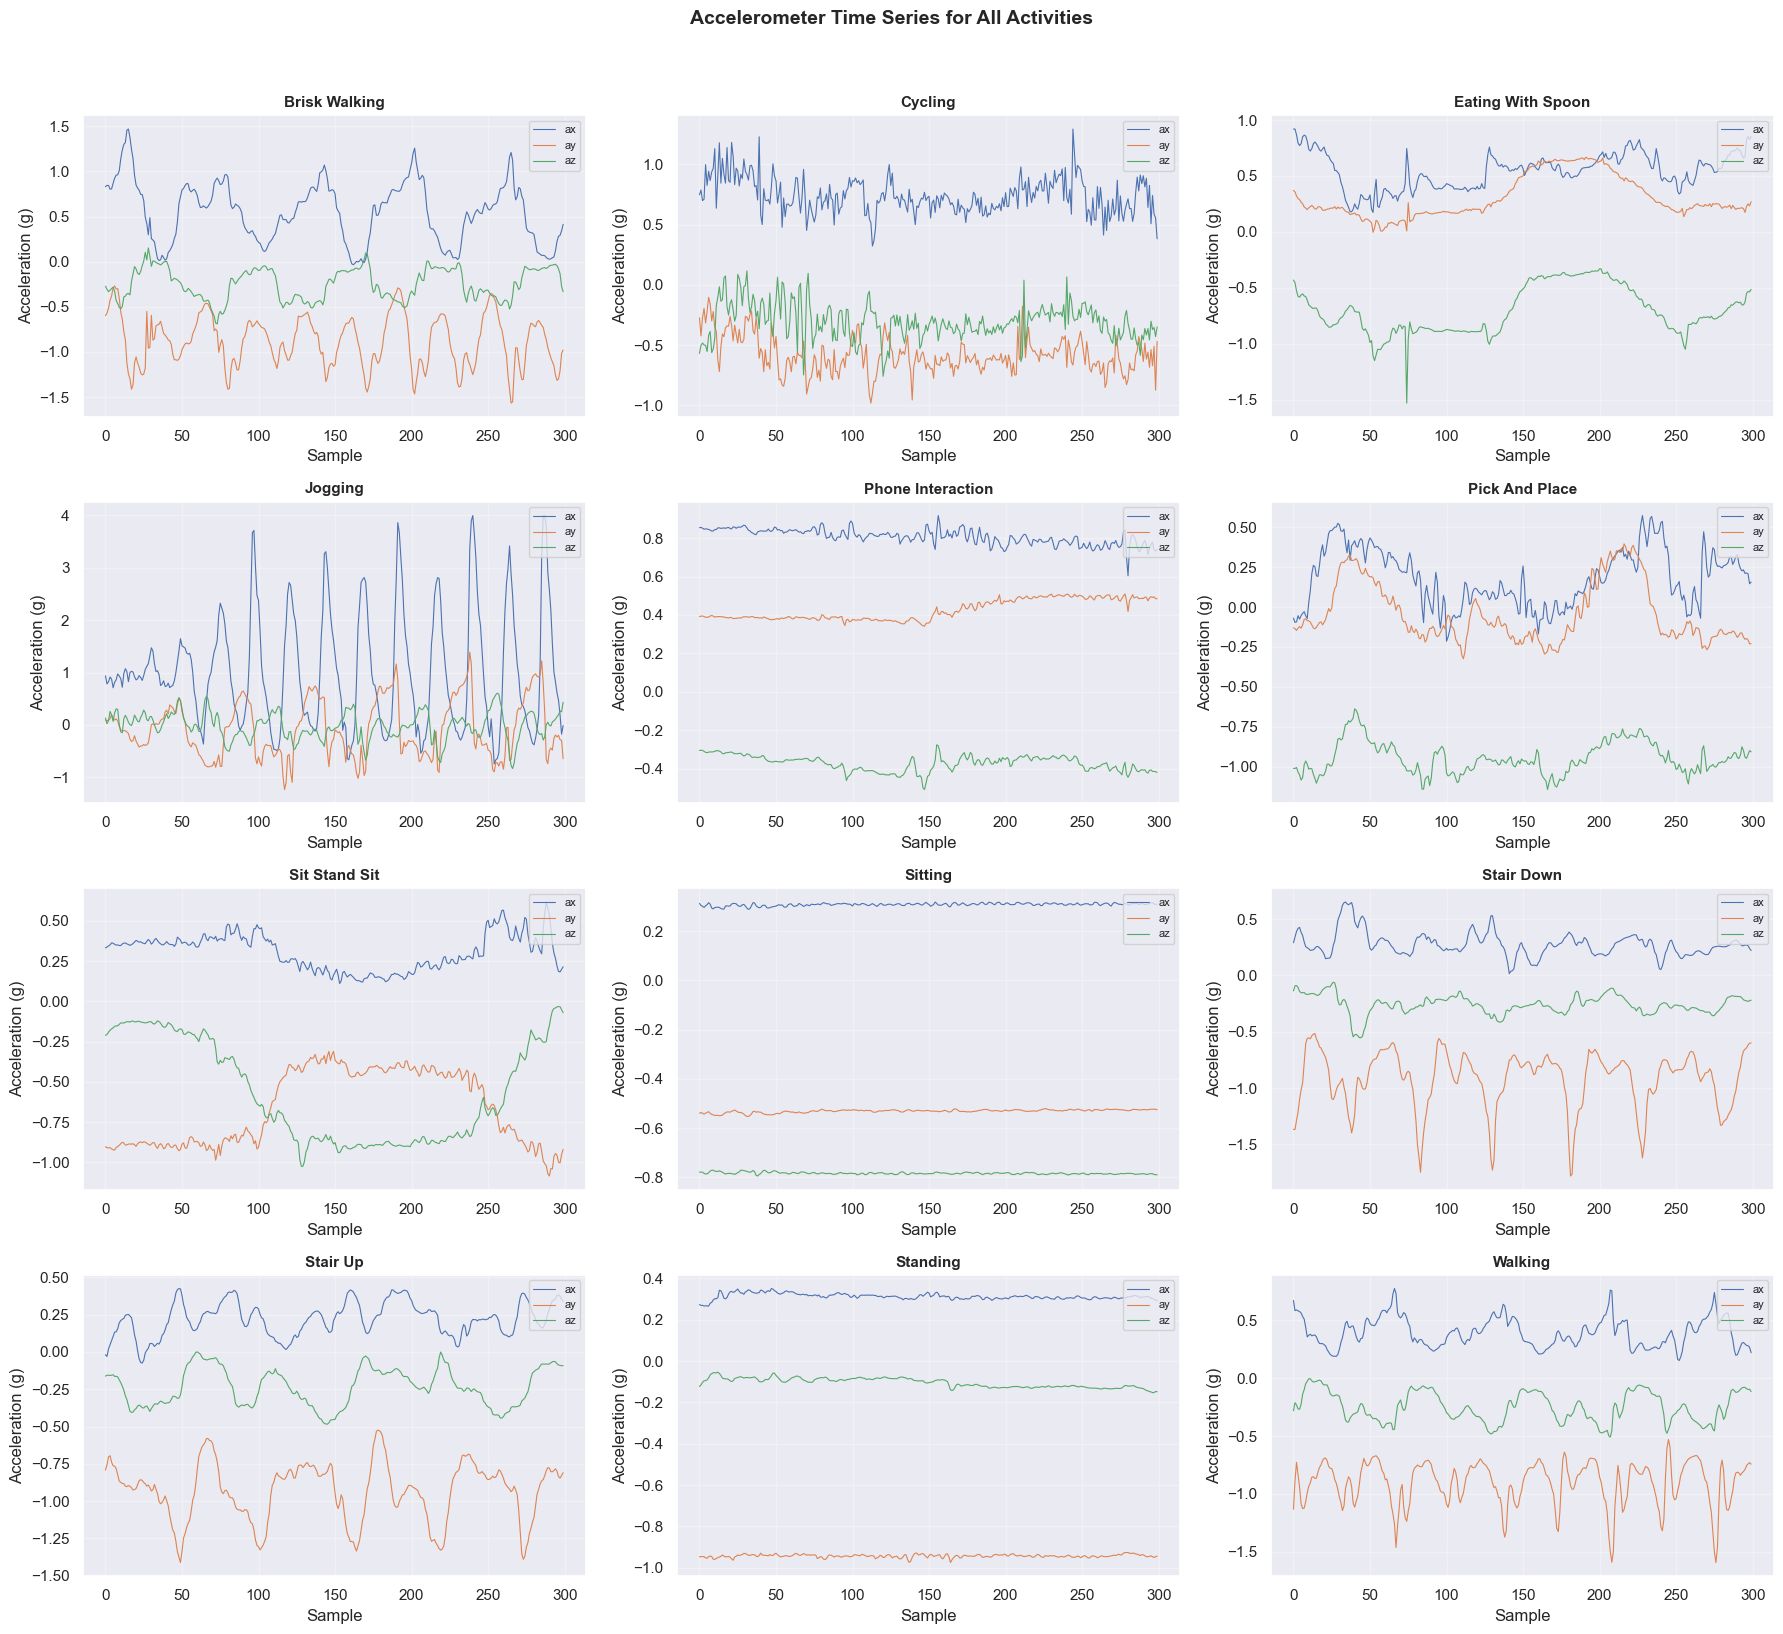

In [9]:
# Time Series Visualization for All Activities
print("📈 Time Series Plots for All 12 Activities")
print("-" * 50)

# Create subplots for all activities
n_activities = len(combined_eda)
n_cols = 3
n_rows = (n_activities + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), sharex=False)
axes = axes.flatten()

sample_size = 300  # Show first 300 samples

for idx, (activity, df) in enumerate(sorted(combined_eda.items())):
    ax = axes[idx]
    
    # Get IMU columns
    imu_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    available_cols = [c for c in imu_cols if c in df.columns]
    
    # Plot accelerometer data
    plot_data = df[available_cols[:3]].iloc[:sample_size]
    plot_data.plot(ax=ax, linewidth=0.8)
    
    ax.set_title(f'{activity.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Acceleration (g)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(combined_eda), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Accelerometer Time Series for All Activities', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

📊 Distribution Plots (KDE) for Accelerometer Axes
--------------------------------------------------


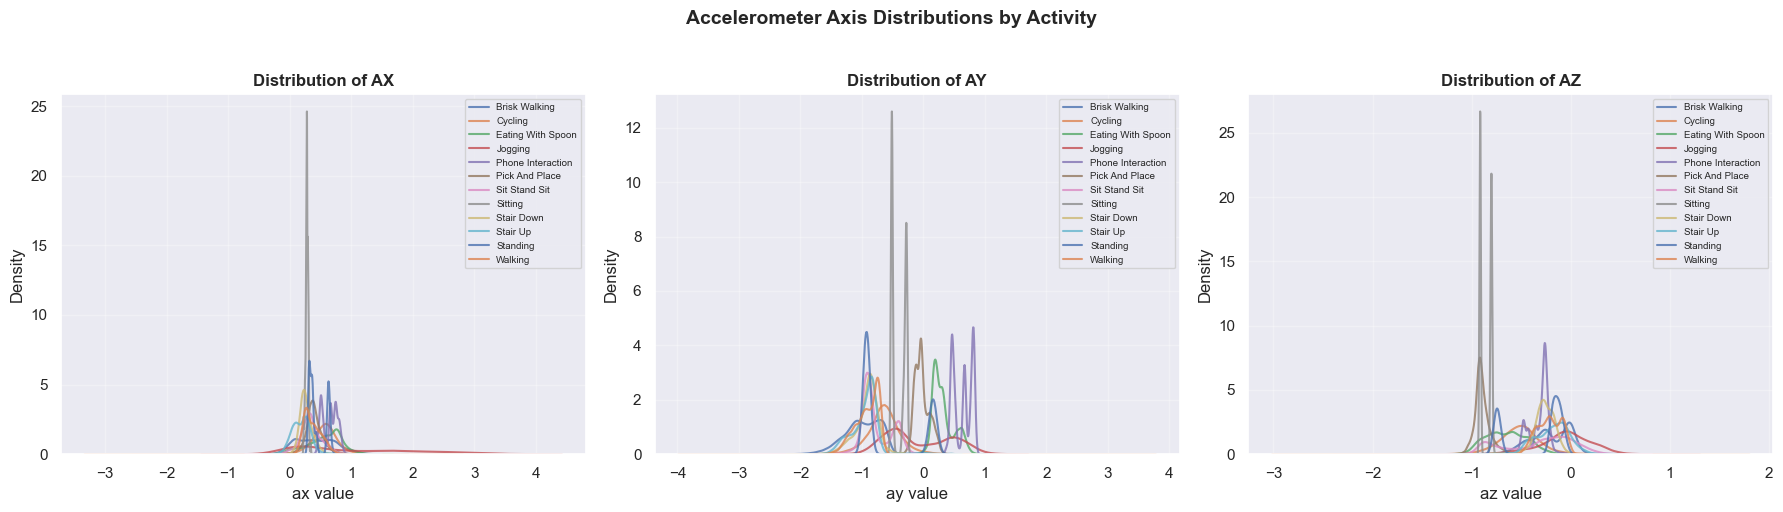


📊 Distribution Plots (KDE) for Gyroscope Axes
--------------------------------------------------


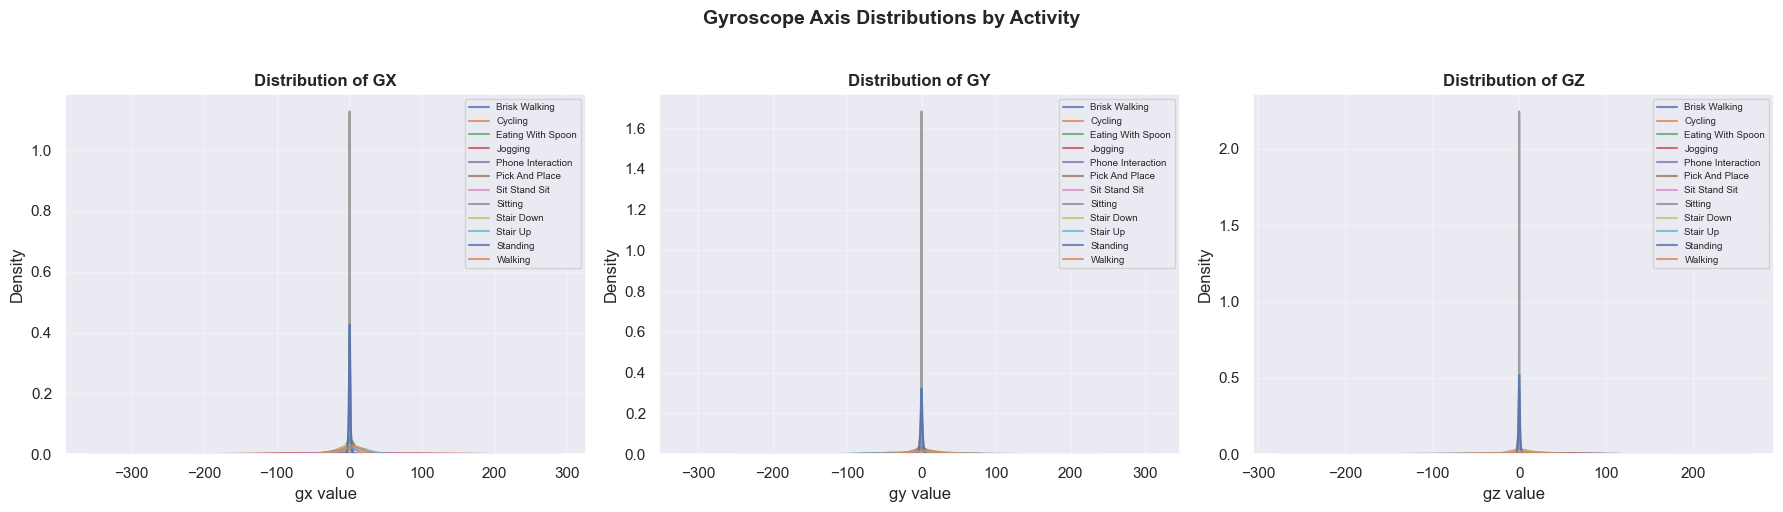

In [10]:
# KDE Distribution Plots
print("📊 Distribution Plots (KDE) for Accelerometer Axes")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
imu_cols_accel = ['ax', 'ay', 'az']

for idx, col in enumerate(imu_cols_accel):
    ax = axes[idx]
    for activity in sorted(combined_eda.keys()):
        df = combined_eda[activity]
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                sns.kdeplot(data=data, ax=ax, label=activity.replace('_', ' ').title(), 
                           fill=False, linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'Distribution of {col.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{col} value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Accelerometer Axis Distributions by Activity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Gyroscope distributions
print("\n📊 Distribution Plots (KDE) for Gyroscope Axes")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
imu_cols_gyro = ['gx', 'gy', 'gz']

for idx, col in enumerate(imu_cols_gyro):
    ax = axes[idx]
    for activity in sorted(combined_eda.keys()):
        df = combined_eda[activity]
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                sns.kdeplot(data=data, ax=ax, label=activity.replace('_', ' ').title(),
                           fill=False, linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'Distribution of {col.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{col} value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Gyroscope Axis Distributions by Activity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

📦 Boxplots for Accelerometer Axes by Activity
--------------------------------------------------


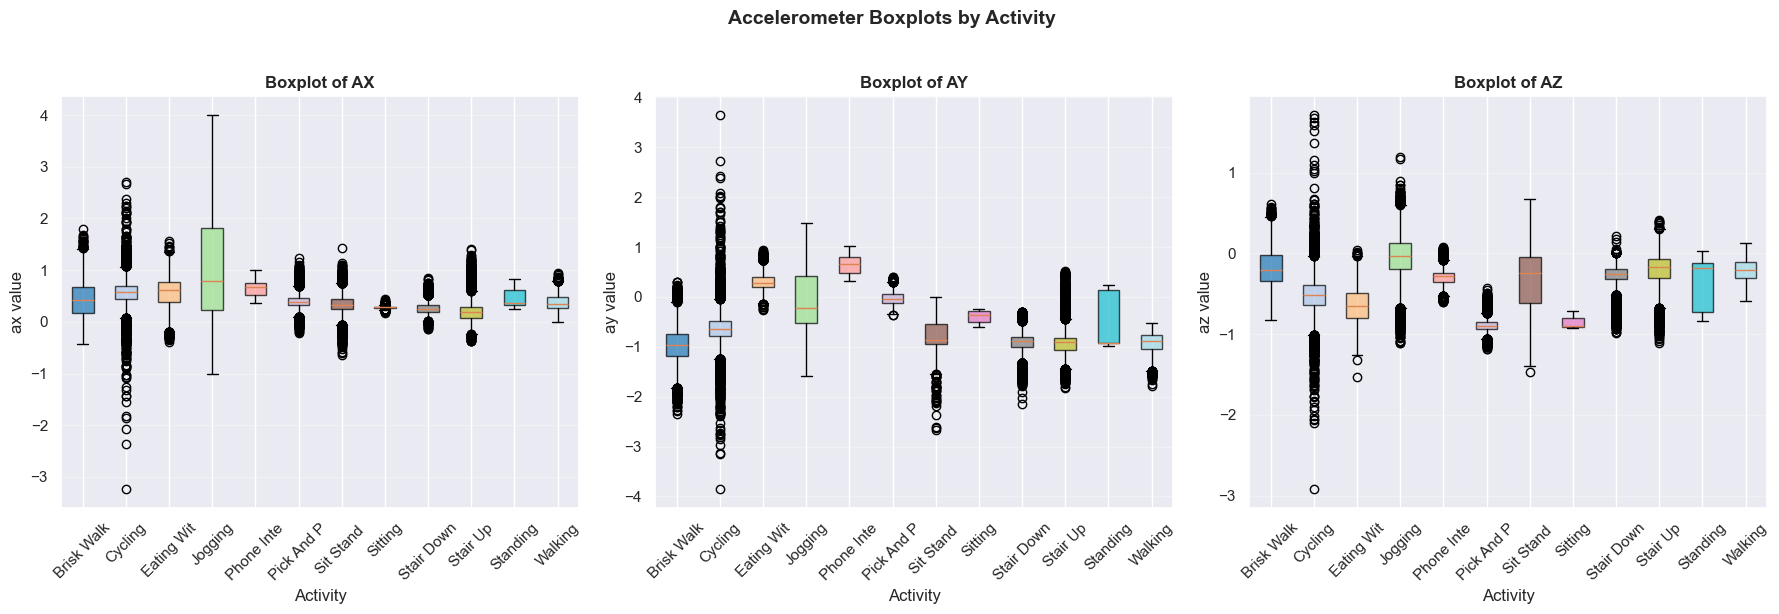

📦 Boxplots for Gyroscope Axes by Activity
--------------------------------------------------


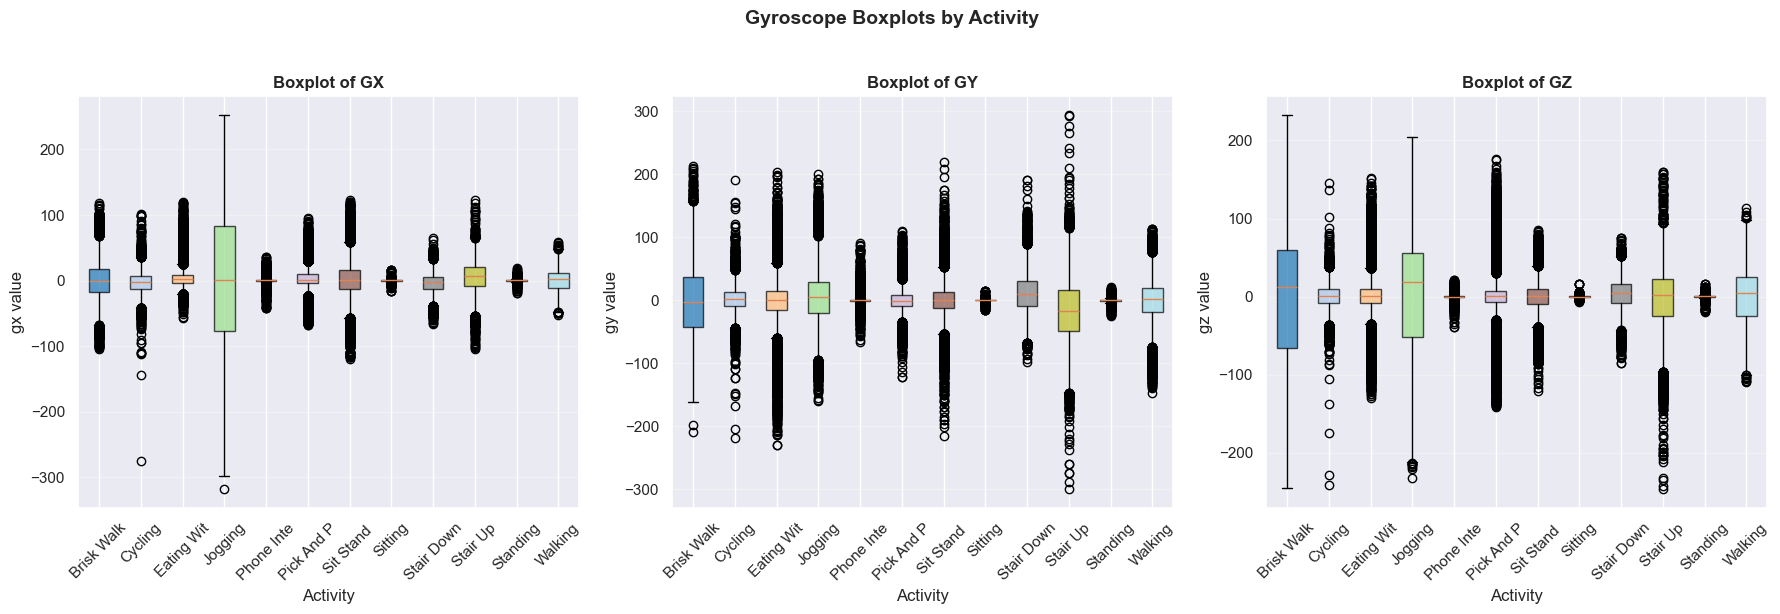

In [13]:
# Boxplots for All Activities
print("📦 Boxplots for Accelerometer Axes by Activity")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, col in enumerate(['ax', 'ay', 'az']):
    ax = axes[idx]
    box_data = []
    labels = []
    for activity in sorted(combined_eda.keys()):
        df = combined_eda[activity]
        if col in df.columns:
            box_data.append(df[col].dropna().values)
            labels.append(activity.replace('_', ' ').title()[:10])
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True)
    cmap = plt.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, len(box_data)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'Boxplot of {col.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Activity')
    ax.set_ylabel(f'{col} value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Accelerometer Boxplots by Activity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📦 Boxplots for Gyroscope Axes by Activity")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, col in enumerate(['gx', 'gy', 'gz']):
    ax = axes[idx]
    box_data = []
    labels = []
    for activity in sorted(combined_eda.keys()):
        df = combined_eda[activity]
        if col in df.columns:
            box_data.append(df[col].dropna().values)
            labels.append(activity.replace('_', ' ').title()[:10])
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True)
    cmap = plt.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, len(box_data)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'Boxplot of {col.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Activity')
    ax.set_ylabel(f'{col} value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Gyroscope Boxplots by Activity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape (X_train): {X_train.shape}")
print(f"Test set shape (X_test): {X_test.shape}")

train_label_counts = dict(zip(*np.unique(y_train, return_counts=True)))
test_label_counts = dict(zip(*np.unique(y_test, return_counts=True)))
print(f"Training label distribution: {train_label_counts}")
print(f"Test label distribution: {test_label_counts}")

Training set shape (X_train): (21455, 126)
Test set shape (X_test): (5364, 126)
Training label distribution: {np.int64(0): np.int64(2871), np.int64(1): np.int64(4306), np.int64(2): np.int64(1431), np.int64(3): np.int64(1431), np.int64(4): np.int64(1428), np.int64(5): np.int64(1433), np.int64(6): np.int64(1376), np.int64(7): np.int64(1435), np.int64(8): np.int64(1434), np.int64(9): np.int64(1438), np.int64(10): np.int64(1436), np.int64(11): np.int64(1436)}
Test label distribution: {np.int64(0): np.int64(718), np.int64(1): np.int64(1077), np.int64(2): np.int64(358), np.int64(3): np.int64(358), np.int64(4): np.int64(357), np.int64(5): np.int64(358), np.int64(6): np.int64(344), np.int64(7): np.int64(358), np.int64(8): np.int64(359), np.int64(9): np.int64(359), np.int64(10): np.int64(359), np.int64(11): np.int64(359)}


## Cross-Validation Strategies Comparison

We compare different CV strategies to understand their impact on model evaluation:
- **KFold**: Simple K-fold split without class balancing
- **StratifiedKFold**: Preserves class ratios in each fold (preferred for classification)
- **ShuffleSplit**: Random train/test splits repeated multiple times
- **StratifiedShuffleSplit**: Random splits with class balance
- **TimeSeriesSplit**: Respects temporal order (no shuffling)

CROSS-VALIDATION STRATEGIES COMPARISON

📊 CV Strategy Comparison (Decision Tree, default params):
                            Strategy  Mean Accuracy      Std      Min      Max
          ShuffleSplit (5, test=0.2)       0.943438 0.002312 0.941089 0.947800
                  KFold (5, shuffle)       0.942914 0.002530 0.940716 0.947800
        StratifiedKFold (5, shuffle)       0.940900 0.004044 0.933818 0.944817
StratifiedShuffleSplit (5, test=0.2)       0.940119 0.001267 0.938479 0.941834
                 TimeSeriesSplit (5)       0.123115 0.095685 0.003133 0.207876


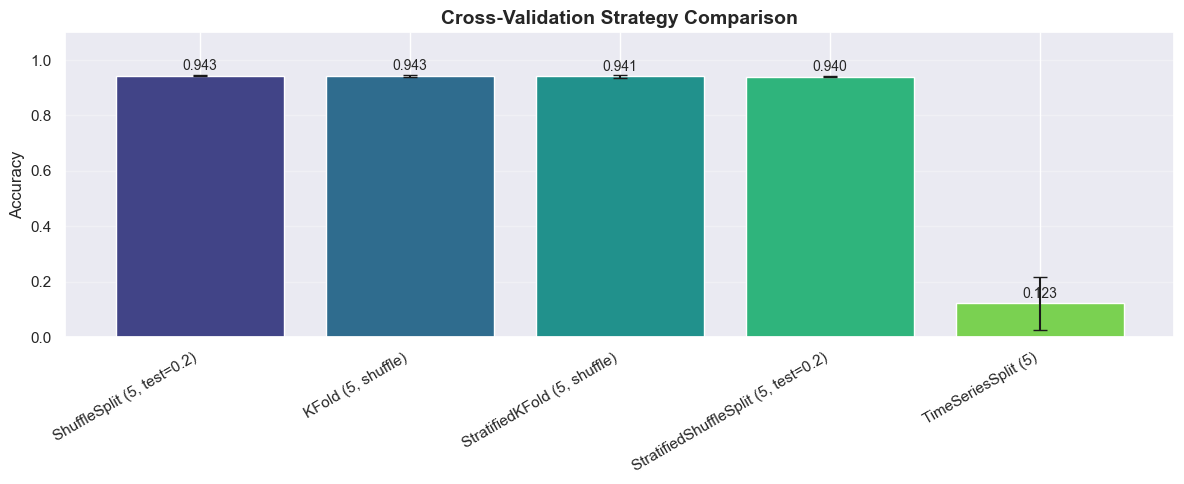


💡 Insights:
  • StratifiedKFold/StratifiedShuffleSplit preserve class ratios - best for imbalanced data
  • TimeSeriesSplit respects temporal order - use if data has time dependence
  • Higher std indicates more variance between folds


In [10]:
# Cross-Validation Strategies Comparison
print("=" * 60)
print("CROSS-VALIDATION STRATEGIES COMPARISON")
print("=" * 60)

def cv_result(name, splitter, clf=None):
    """Evaluate a classifier using a specific CV strategy."""
    if clf is None:
        clf = DecisionTreeClassifier(random_state=42)
    scores = cross_val_score(clf, X, y, cv=splitter, scoring='accuracy', n_jobs=-1)
    return {
        'Strategy': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    }

cv_results = []

# 1. KFold
cv_results.append(cv_result('KFold (5, shuffle)', 
                            KFold(n_splits=5, shuffle=True, random_state=42)))

# 2. StratifiedKFold
cv_results.append(cv_result('StratifiedKFold (5, shuffle)', 
                            StratifiedKFold(n_splits=5, shuffle=True, random_state=42)))

# 3. ShuffleSplit
cv_results.append(cv_result('ShuffleSplit (5, test=0.2)', 
                            ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)))

# 4. StratifiedShuffleSplit
cv_results.append(cv_result('StratifiedShuffleSplit (5, test=0.2)', 
                            StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)))

# 5. TimeSeriesSplit
cv_results.append(cv_result('TimeSeriesSplit (5)', 
                            TimeSeriesSplit(n_splits=5)))

cv_compare_df = pd.DataFrame(cv_results)
cv_compare_df = cv_compare_df.sort_values('Mean Accuracy', ascending=False)

print("\n📊 CV Strategy Comparison (Decision Tree, default params):")
print(cv_compare_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cv_compare_df))
bars = ax.bar(x, cv_compare_df['Mean Accuracy'], yerr=cv_compare_df['Std'], 
              capsize=5, color=plt.get_cmap('viridis')(np.linspace(0.2, 0.8, len(cv_compare_df))))
ax.set_xticks(x)
ax.set_xticklabels(cv_compare_df['Strategy'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation Strategy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, cv_compare_df['Mean Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Insights:")
print("  • StratifiedKFold/StratifiedShuffleSplit preserve class ratios - best for imbalanced data")
print("  • TimeSeriesSplit respects temporal order - use if data has time dependence")
print("  • Higher std indicates more variance between folds")

## Gini vs Entropy (Split Criteria Comparison)

When a decision tree decides where to split, it tries to make child nodes "purer". Two common impurity measures:

- **Gini Impurity**: $\text{Gini}(S) = 1 - \sum_k p_k^2$
  - Probability of wrong label if randomly labeling according to class frequencies
  - Slightly faster (no logarithms)
  
- **Entropy (Information Gain)**: $H(S) = -\sum_k p_k \log_2 p_k$
  - Information-theoretic measure of uncertainty
  - Splits maximize Information Gain: $IG = H(S) - \sum_i \frac{|S_i|}{|S|} H(S_i)$

GINI vs ENTROPY COMPARISON

📊 Gini vs Entropy Accuracy Comparison:
Max Depth  Gini Mean  Gini Std  Entropy Mean  Entropy Std  Difference
        3   0.554681  0.002488      0.648421     0.002685   -0.093739
        5   0.758940  0.001599      0.829114     0.004693   -0.070174
        7   0.844811  0.005381      0.907193     0.002914   -0.062381
       10   0.912636  0.002803      0.940043     0.005086   -0.027406
       15   0.940564  0.002562      0.948693     0.003178   -0.008129
     None   0.940900  0.004044      0.948022     0.003381   -0.007122


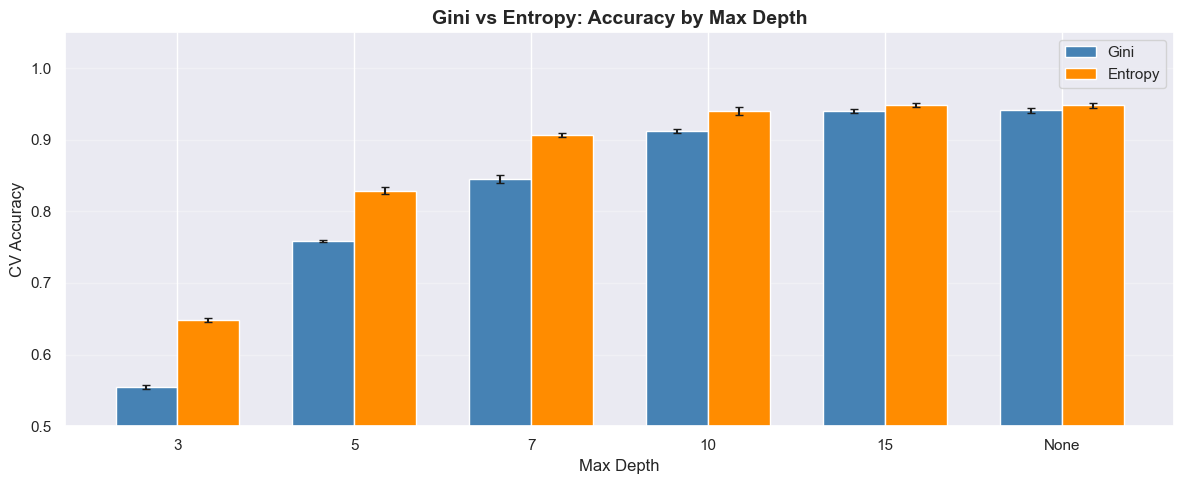


💡 Insights:
  • Both criteria often produce similar results
  • Gini is slightly faster computationally (no logarithms)
  • Entropy may create more balanced trees in some cases
  • Average difference: -0.0448


In [11]:
# Gini vs Entropy Comparison
print("=" * 60)
print("GINI vs ENTROPY COMPARISON")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare across different max_depths
depths = [3, 5, 7, 10, 15, None]
gini_vs_entropy = []

for depth in depths:
    depth_str = str(depth) if depth else 'None'
    
    # Gini
    clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    scores_gini = cross_val_score(clf_gini, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    
    # Entropy
    clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    scores_entropy = cross_val_score(clf_entropy, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    
    gini_vs_entropy.append({
        'Max Depth': depth_str,
        'Gini Mean': scores_gini.mean(),
        'Gini Std': scores_gini.std(),
        'Entropy Mean': scores_entropy.mean(),
        'Entropy Std': scores_entropy.std(),
        'Difference': scores_gini.mean() - scores_entropy.mean()
    })

gini_entropy_df = pd.DataFrame(gini_vs_entropy)
print("\n📊 Gini vs Entropy Accuracy Comparison:")
print(gini_entropy_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(depths))
width = 0.35

bars1 = ax.bar(x - width/2, gini_entropy_df['Gini Mean'], width, 
               yerr=gini_entropy_df['Gini Std'], label='Gini', capsize=3, color='steelblue')
bars2 = ax.bar(x + width/2, gini_entropy_df['Entropy Mean'], width, 
               yerr=gini_entropy_df['Entropy Std'], label='Entropy', capsize=3, color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels([str(d) if d else 'None' for d in depths])
ax.set_xlabel('Max Depth')
ax.set_ylabel('CV Accuracy')
ax.set_title('Gini vs Entropy: Accuracy by Max Depth', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Insights:")
print("  • Both criteria often produce similar results")
print("  • Gini is slightly faster computationally (no logarithms)")
print("  • Entropy may create more balanced trees in some cases")
print(f"  • Average difference: {gini_entropy_df['Difference'].mean():.4f}")

In [12]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import numpy as np

# Check if required data variables exist
# This is a safeguard to ensure the data is loaded before proceeding.
try:
    X_train, X_test, y_train, y_test
except NameError as e:
    print(f"Error: {e}. Please run the data loading and splitting cells first.")
    raise

models_config = {
    "DecisionTree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [6, 8, 10, 12, None],
            "min_samples_split": [5, 10, 15],
            "min_samples_leaf": [2, 4, 6],
            "max_features": ["sqrt", 0.5, None],
            "ccp_alpha": [0.0, 0.001, 0.01]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "criterion": ["gini", "entropy"],
            "max_depth": [6, 8, 10],
            "min_samples_split": [5, 10],
            "min_samples_leaf": [2, 4],
            "max_features": ["sqrt", 0.5]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'),
        "params": {
            "penalty": ["l1", "l2"],
            "C": [0.1, 1, 10],
            "solver": ["liblinear"]
        }
    }
}

best_models = {}
results_summary = []

def create_objective(name, config, X_tr, y_tr):
    """Factory function to create an Optuna objective function for a specific model."""
    def objective(trial):
        # Dynamically suggest parameters based on the config's keys
        params = {}
        for param_name, choices in config["params"].items():
            # Note: suggest_categorical handles strings, ints, and floats from lists correctly
            params[param_name] = trial.suggest_categorical(param_name, choices)
        
        # Create model instance with suggested parameters
        # Use the model's class to allow instantiation with new parameters
        model_class = config["model"].__class__
        model_instance = model_class(**params, random_state=42)
        
        # Use cross-validation to evaluate the model on the TRAINING set
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model_instance, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)
        cv_accuracy = scores.mean()
        
        # Optuna maximizes the returned value, so we return the CV accuracy
        return cv_accuracy
    # Return the inner objective function, which now captures X_tr, y_tr
    return objective


for name, config in models_config.items():
    print(f"\n--- Tuning {name} ---")
    
    # Create the objective function for the current model, passing ONLY training data
    objective_func = create_objective(name, config, X_train, y_train)
    
    # Create an Optuna study object (direction='maximize' because we want to maximize accuracy)
    study = optuna.create_study(direction='maximize')
    
    # Run the optimization (e.g., 50 trials)
    study.optimize(objective_func, n_trials=100)
    
    # Get the best parameters found by Optuna
    best_params = study.best_params
    
    # Train the final model using the best parameters on the FULL training set
    best_model_class = config["model"].__class__
    best_model = best_model_class(**best_params, random_state=42)
    best_model.fit(X_train, y_train)  # Fit on the entire training set
    
    # Store the trained best model
    best_models[name] = best_model
    
    # Evaluate the best model on the TEST set
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Best params for {name}: {best_params}")
    print(f"Test Accuracy ({name}): {acc:.4f}")
    print(f"Test F1 Macro ({name}): {f1_macro:.4f}")
    print(f"Test F1 Weighted ({name}): {f1_weighted:.4f}")
    print(f"Confusion Matrix ({name}):\n{cm}")
    
    # Append results to the summary list
    results_summary.append({
        "Model": name, 
        "Accuracy": acc, 
        "F1_Macro": f1_macro,
        "F1_Weighted": f1_weighted,
        "Best_Params": best_params
    })


[I 2026-02-03 23:53:11,753] A new study created in memory with name: no-name-6590a8b5-5bc2-4364-9e5b-1b857357b106



--- Tuning DecisionTree ---


[I 2026-02-03 23:53:12,218] Trial 0 finished with value: 0.8107201118620366 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.01}. Best is trial 0 with value: 0.8107201118620366.
[I 2026-02-03 23:53:14,469] Trial 1 finished with value: 0.8828245164297366 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 0.5, 'ccp_alpha': 0.01}. Best is trial 1 with value: 0.8828245164297366.
[I 2026-02-03 23:53:14,788] Trial 2 finished with value: 0.7414588673968772 and parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'ccp_alpha': 0.0}. Best is trial 1 with value: 0.8828245164297366.
[I 2026-02-03 23:53:19,048] Trial 3 finished with value: 0.936005593101841 and parameters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_fe

Best params for DecisionTree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'ccp_alpha': 0.0}
Test Accuracy (DecisionTree): 0.9448
Test F1 Macro (DecisionTree): 0.9329
Test F1 Weighted (DecisionTree): 0.9449
Confusion Matrix (DecisionTree):
[[ 714    0    0    0    0    0    0    1    3    0    0    0]
 [   0 1063    0    0    0    0    0    0    8    0    5    1]
 [   0    0  314    8    0    0   15   20    1    0    0    0]
 [   0    0   11  331    0    1   11    1    2    0    1    0]
 [   0    0    0    0  353    2    0    0    2    0    0    0]
 [   0    0    0    1    0  356    1    0    0    0    0    0]
 [   0    0    8   16    0    0  282   19   16    1    1    1]
 [   0    0   15    2    0    0   17  299   25    0    0    0]
 [   0    8    8    5    0    0   13   16  308    0    0    1]
 [   0    0    0    0    0    0    0    0    0  358    1    0]
 [   0    3    0    0    0    0    3    0    0    8  341    4]


[I 2026-02-03 23:58:34,686] Trial 0 finished with value: 0.9594500116522955 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9594500116522955.
[I 2026-02-03 23:58:47,896] Trial 1 finished with value: 0.9252388720577954 and parameters: {'n_estimators': 50, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9594500116522955.
[I 2026-02-03 23:59:02,565] Trial 2 finished with value: 0.9593101841062689 and parameters: {'n_estimators': 50, 'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9594500116522955.
[I 2026-02-03 23:59:32,530] Trial 3 finished with value: 0.8413889536238639 and parameters: {'n_estimators': 50, 'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 5, 'min

Best params for RandomForest: {'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Test Accuracy (RandomForest): 0.9735
Test F1 Macro (RandomForest): 0.9676
Test F1 Weighted (RandomForest): 0.9735
Confusion Matrix (RandomForest):
[[ 715    0    0    0    0    0    0    0    3    0    0    0]
 [   0 1069    0    0    0    0    0    0    4    0    4    0]
 [   0    0  331    5    0    0    1   20    1    0    0    0]
 [   0    0    5  350    0    0    2    0    0    0    1    0]
 [   0    0    0    1  356    0    0    0    0    0    0    0]
 [   0    0    0    0    0  358    0    0    0    0    0    0]
 [   0    0    6   10    0    0  306   16    2    0    3    1]
 [   0    0   19    1    0    0    6  321   11    0    0    0]
 [   0    1    4    0    0    0    4   10  339    0    0    1]
 [   0    0    0    0    0    0    0    0    0  359    0    0]
 [   0    0    0    0    0    0    0    0    0    0  359   

[I 2026-02-04 00:46:45,128] Trial 0 finished with value: 0.9657422512234909 and parameters: {'penalty': 'l1', 'C': 1, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9657422512234909.
[I 2026-02-04 00:47:13,405] Trial 1 finished with value: 0.9506874854346306 and parameters: {'penalty': 'l1', 'C': 0.1, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9657422512234909.
[I 2026-02-04 00:48:25,822] Trial 2 finished with value: 0.8376602190631555 and parameters: {'penalty': 'l2', 'C': 0.1, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9657422512234909.
[I 2026-02-04 00:49:37,288] Trial 3 finished with value: 0.8225588440922861 and parameters: {'penalty': 'l2', 'C': 1, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9657422512234909.
[I 2026-02-04 00:50:42,901] Trial 4 finished with value: 0.9657422512234909 and parameters: {'penalty': 'l1', 'C': 1, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9657422512234909.
[I 2026-02-04 00:51:11,314] Trial 5 finished w

Best params for LogisticRegression: {'penalty': 'l1', 'C': 10, 'solver': 'liblinear'}
Test Accuracy (LogisticRegression): 0.9679
Test F1 Macro (LogisticRegression): 0.9622
Test F1 Weighted (LogisticRegression): 0.9678
Confusion Matrix (LogisticRegression):
[[ 715    0    0    0    0    0    0    0    3    0    0    0]
 [   0 1066    0    0    0    0    0    0    4    0    5    2]
 [   0    0  342    1    0    0    1   12    2    0    0    0]
 [   0    0    8  348    1    0    1    0    0    0    0    0]
 [   0    0    0    2  355    0    0    0    0    0    0    0]
 [   0    0    0    0    0  358    0    0    0    0    0    0]
 [   0    0    7    6    0    0  307   12    8    0    1    3]
 [   0    0    5    0    0    0   10  328   15    0    0    0]
 [   2   13    6    2    0    0    9   16  309    0    0    2]
 [   0    0    0    0    0    0    0    0    0  359    0    0]
 [   0    6    0    0    0    1    0    0    0    0  351    1]
 [   0    1    0    0    0    0    0    0    2    

In [13]:
import pandas as pd
results_df = pd.DataFrame(results_summary)
print("\n--- Model Comparison Summary ---")
print(results_df.to_string(index=False))


--- Model Comparison Summary ---
             Model  Accuracy  F1_Macro  F1_Weighted                                                                                                                           Best_Params
      DecisionTree  0.944817  0.932944     0.944920     {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'ccp_alpha': 0.0}
      RandomForest  0.973527  0.967603     0.973539 {'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
LogisticRegression  0.967934  0.962228     0.967790                                                                                     {'penalty': 'l1', 'C': 10, 'solver': 'liblinear'}


## Feature Importance Analysis

Feature importance shows which features contribute most to the Decision Tree's predictions. This helps understand what the model learned and can guide feature engineering.

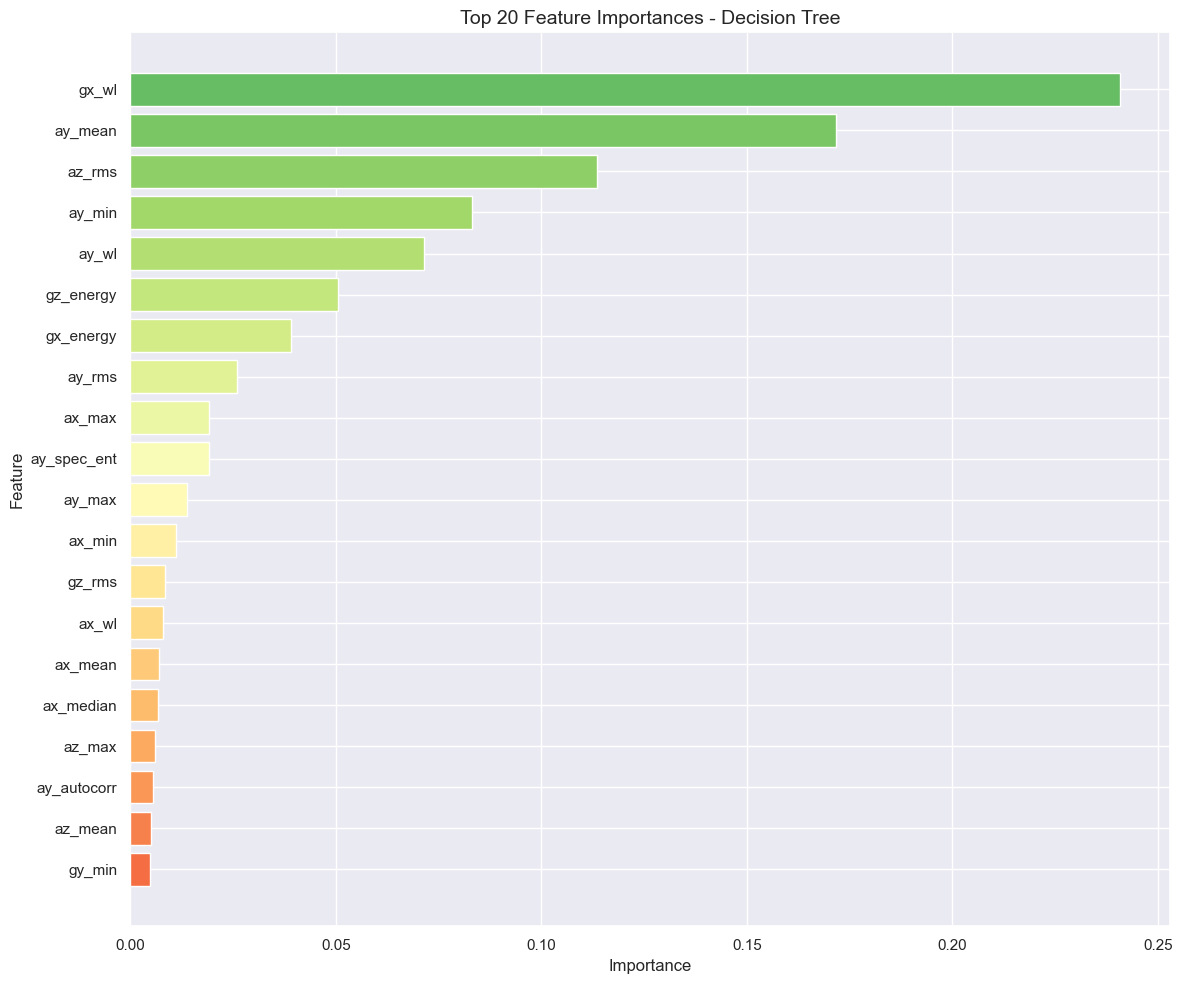


📊 Top 10 Most Important Features:
--------------------------------------------------
  gx_wl: 0.2409
  ay_mean: 0.1717
  az_rms: 0.1136
  ay_min: 0.0830
  ay_wl: 0.0714
  gz_energy: 0.0504
  gx_energy: 0.0391
  ay_rms: 0.0258
  ax_max: 0.0192
  ay_spec_ent: 0.0192


In [14]:
# Feature Importance Analysis for Decision Tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a Decision Tree with best parameters from Optuna (or default balanced)
dt_model = best_models["DecisionTree"]

importances = dt_model.feature_importances_

imu_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
stat_names = ['mean', 'std', 'min', 'max', 'range', 'var', 'skew', 'kurt', 'energy', 'entropy', 
              'rms', 'zcr', 'mad', 'median', 'iqr', 'autocorr', 'wl', 'dom_freq', 'spec_ent', 'std_jerk']

feature_names = []
for col in imu_cols:
    for stat in stat_names:
        feature_names.append(f"{col}_{stat}")
feature_names.extend([f"{col}_raw_last" for col in imu_cols]) # Total 126 features

# Create DataFrame for easier manipulation
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot top 20 features (horizontal bar chart)
plt.figure(figsize=(12, 10))
top_n = min(20, len(feat_importance_df))
top_features = feat_importance_df.tail(top_n)
colors = plt.get_cmap('RdYlGn')(np.linspace(0.2, 0.8, top_n))
plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Feature Importances - Decision Tree', fontsize=14)
plt.tight_layout()
plt.show()

# Print top 10 features
print("\n📊 Top 10 Most Important Features:")
print("-" * 50)
for idx, row in feat_importance_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

## Model Statistics and Serialization

After training, we analyze the Decision Tree structure (depth, node count) and save it using joblib to measure its serialized size for embedded deployment.

In [15]:
# Model Statistics and Joblib Serialization
import joblib
import os

# Get model statistics
tree_depth = dt_model.get_depth()
node_count = dt_model.tree_.node_count
n_leaves = dt_model.get_n_leaves()
n_features = dt_model.n_features_in_
n_classes = dt_model.n_classes_

print("🌳 Decision Tree Model Statistics")
print("=" * 50)
print(f"  Tree Depth:        {tree_depth}")
print(f"  Total Nodes:       {node_count}")
print(f"  Leaf Nodes:        {n_leaves}")
print(f"  Internal Nodes:    {node_count - n_leaves}")
print(f"  Number of Features: {n_features}")
print(f"  Number of Classes:  {n_classes}")

# Save model with joblib
model_path = 'decision_tree_model.joblib'
joblib.dump(dt_model, model_path)
file_size_bytes = os.path.getsize(model_path)
file_size_kb = file_size_bytes / 1024

print("\n💾 Model Serialization")
print("-" * 50)
print(f"  Model saved to: {model_path}")
print(f"  File size: {file_size_bytes} bytes ({file_size_kb:.2f} KB)")

# Test accuracy
from sklearn.metrics import accuracy_score
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📈 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

🌳 Decision Tree Model Statistics
  Tree Depth:        18
  Total Nodes:       851
  Leaf Nodes:        426
  Internal Nodes:    425
  Number of Features: 126
  Number of Classes:  12

💾 Model Serialization
--------------------------------------------------
  Model saved to: decision_tree_model.joblib
  File size: 137529 bytes (134.31 KB)

📈 Test Accuracy: 0.9448 (94.48%)


## Without CV vs With CV Comparison

Comparing a single train-test split (without CV) versus cross-validation provides insight into model stability and generalization. CV reduces variance in performance estimates.

📊 WITHOUT Cross-Validation (Single Train-Test Split)
  Training Accuracy: 0.9126
  Test Accuracy:     0.9012
  Overfit Gap:       0.0114

📊 WITH Cross-Validation (Stratified 5-Fold)
  Fold Accuracies: [0.89280388 0.88646532 0.89112603 0.89765101 0.89166511]
  Mean Accuracy:   0.8919
  Std Deviation:   0.0036
  95% CI:          [0.8849, 0.8990]

📈 Comparison Summary
                     Method  Accuracy  Std Dev      Reliable Estimate
  Without CV (Single Split)  0.901193      NaN    ❌ No (Single point)
With CV (Stratified 5-Fold)  0.891942  0.00358 ✅ Yes (Multiple folds)


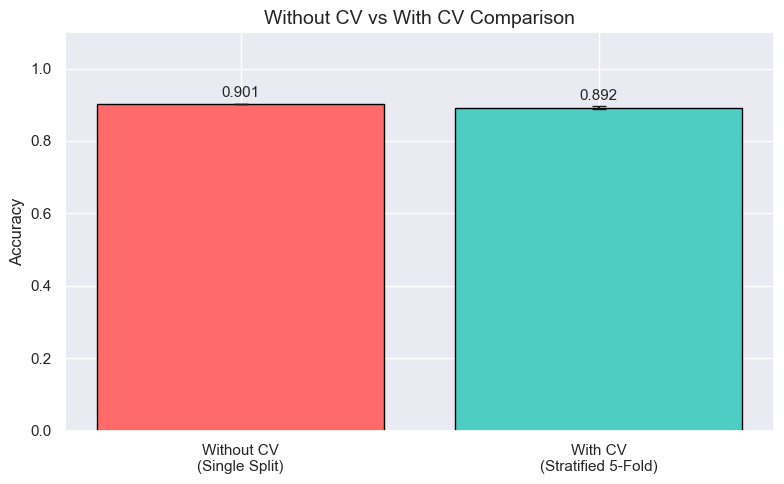

In [16]:
# Without CV vs With CV Comparison
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Same model configuration
dt_config = {
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'criterion': 'gini',
    'class_weight': 'balanced',
    'random_state': 42
}

# WITHOUT Cross-Validation (Single Split)
print("📊 WITHOUT Cross-Validation (Single Train-Test Split)")
print("=" * 60)
dt_no_cv = DecisionTreeClassifier(**dt_config)
dt_no_cv.fit(X_train, y_train)
train_acc_no_cv = dt_no_cv.score(X_train, y_train)
test_acc_no_cv = dt_no_cv.score(X_test, y_test)
print(f"  Training Accuracy: {train_acc_no_cv:.4f}")
print(f"  Test Accuracy:     {test_acc_no_cv:.4f}")
print(f"  Overfit Gap:       {train_acc_no_cv - test_acc_no_cv:.4f}")

# WITH Cross-Validation (Stratified 5-Fold)
print("\n📊 WITH Cross-Validation (Stratified 5-Fold)")
print("=" * 60)
dt_cv = DecisionTreeClassifier(**dt_config)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_cv, X, y, cv=skf, scoring='accuracy')

print(f"  Fold Accuracies: {cv_scores}")
print(f"  Mean Accuracy:   {cv_scores.mean():.4f}")
print(f"  Std Deviation:   {cv_scores.std():.4f}")
print(f"  95% CI:          [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

# Visual comparison
print("\n📈 Comparison Summary")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Method': ['Without CV (Single Split)', 'With CV (Stratified 5-Fold)'],
    'Accuracy': [test_acc_no_cv, cv_scores.mean()],
    'Std Dev': [np.nan, cv_scores.std()],
    'Reliable Estimate': ['❌ No (Single point)', '✅ Yes (Multiple folds)']
})
print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Without CV\n(Single Split)', 'With CV\n(Stratified 5-Fold)']
accuracies = [test_acc_no_cv, cv_scores.mean()]
errors = [0, cv_scores.std()]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(methods, accuracies, yerr=errors, capsize=5, color=colors, edgecolor='black')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Without CV vs With CV Comparison', fontsize=14)
ax.set_ylim(0, 1.1)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Human-Readable Text Tree

Export the Decision Tree as a text representation for debugging and understanding the learned decision rules.

In [17]:
# Human-Readable Text Tree
from sklearn.tree import export_text

# Get class names from label encoder
class_names = [reverse_label_map[i] for i in sorted(reverse_label_map.keys())]

# Export tree as text (limit depth for readability)
tree_text = export_text(dt_model, feature_names=feature_names, max_depth=5)

print("🌳 Decision Tree Text Representation (max_depth=5 for readability)")
print("=" * 80)
print(tree_text)

# Also save full tree to file
full_tree_text = export_text(dt_model, feature_names=feature_names)
with open('decision_tree_rules.txt', 'w') as f:
    f.write(full_tree_text)
print(f"\n💾 Full tree saved to 'decision_tree_rules.txt' ({len(full_tree_text)} characters)")

🌳 Decision Tree Text Representation (max_depth=5 for readability)
|--- gx_wl <= 12.70
|   |--- az_rms <= 0.78
|   |   |--- ay_min <= 0.34
|   |   |   |--- ax_median <= 0.71
|   |   |   |   |--- ay_std_jerk <= 0.01
|   |   |   |   |   |--- ay_min <= 0.19
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- ay_min >  0.19
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- ay_std_jerk >  0.01
|   |   |   |   |   |--- gy_energy <= 1179.20
|   |   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |   |--- gy_energy >  1179.20
|   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ax_median >  0.71
|   |   |   |   |--- ax_rms <= 0.73
|   |   |   |   |   |--- class: 10
|   |   |   |   |--- ax_rms >  0.73
|   |   |   |   |   |--- class: 10
|   |   |--- ay_min >  0.34
|   |   |   |--- ay_mean <= 0.37
|   |   |   |   |--- class: 9
|   |   |   |--- ay_mean >  0.37
|   |   |   |   |--- class: 9
|   |--- az_rm

## Portable Python Code with m2cgen

m2cgen (Model to Code Generator) converts the trained Decision Tree to pure Python code that can run without scikit-learn dependencies - ideal for embedded systems and edge deployment.

In [18]:
%pip install m2cgen


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
try:
    import m2cgen as m2c
    
    # Generate pure Python code
    python_code = m2c.export_to_python(dt_model)
    
    # Save to file
    with open('decision_tree_m2cgen.py', 'w') as f:
        f.write("# Auto-generated Decision Tree classifier using m2cgen\n")
        f.write("# No sklearn dependency required!\n\n")
        f.write(python_code)
        f.write("\n\n# Example usage:\n")
        f.write("# result = score(input_features)  # Returns class scores\n")
        f.write("# predicted_class = result.index(max(result))\n")
    
    print("✅ Portable Python code generated with m2cgen")
    print("=" * 60)
    print(f"💾 Saved to: decision_tree_m2cgen.py")
    print(f"📏 Code size: {len(python_code)} characters")
    print("\n🔍 First 1500 characters of generated code:")
    print("-" * 60)
    print(python_code[:1500] + "..." if len(python_code) > 1500 else python_code)
    
except ImportError:
    print("⚠️ m2cgen not installed. Install with: pip install m2cgen")
    print("   Then re-run this cell.")

✅ Portable Python code generated with m2cgen
💾 Saved to: decision_tree_m2cgen.py
📏 Code size: 103104 characters

🔍 First 1500 characters of generated code:
------------------------------------------------------------
def score(input):
    if input[76] <= 12.695315837860107:
        if input[50] <= 0.7764304876327515:
            if input[22] <= 0.3392944931983948:
                if input[13] <= 0.7066957652568817:
                    if input[39] <= 0.0064901262521743774:
                        if input[22] <= 0.18914800137281418:
                            if input[63] <= 7.659914016723633:
                                var0 = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                            else:
                                var0 = [0.0, 0.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.0, 0.0, 0.0]
                        else:
                            if input[3] <= 0.6287845075130463:
                                var0 = [0.0, 0.5, 0.0, 0.0, 0.0, 0.0,

## Embedded C/C++ Code with micromlgen

micromlgen generates C/C++ code for microcontrollers (Arduino, ESP32, STM32). This enables running the Decision Tree directly on embedded hardware without external libraries.

In [20]:
%pip install micromlgen


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
try:
    from micromlgen import port
    
    # Generate C/C++ code for embedded systems
    c_code = port(dt_model, classmap={i: name for i, name in enumerate(class_names)})
    
    # Save to header file
    with open('decision_tree_embedded.h', 'w') as f:
        f.write("// Auto-generated Decision Tree for embedded systems\n")
        f.write("// Generated using micromlgen\n")
        f.write("// Compatible with Arduino, ESP32, STM32, etc.\n\n")
        f.write(c_code)
    
    print("✅ Embedded C/C++ code generated with micromlgen")
    print("=" * 60)
    print(f"💾 Saved to: decision_tree_embedded.h")
    print(f"📏 Code size: {len(c_code)} characters")
    print("\n🔍 First 2000 characters of generated code:")
    print("-" * 60)
    print(c_code[:2000] + "..." if len(c_code) > 2000 else c_code)
    
except ImportError:
    print("⚠️ micromlgen not installed. Install with: pip install micromlgen")
    print("   Then re-run this cell.")
except Exception as e:
    print(f"⚠️ Error generating C code: {e}")
    print("   micromlgen may have compatibility issues with your model.")

✅ Embedded C/C++ code generated with micromlgen
💾 Saved to: decision_tree_embedded.h
📏 Code size: 157709 characters

🔍 First 2000 characters of generated code:
------------------------------------------------------------
#pragma once
#include <cstdarg>
namespace Eloquent {
    namespace ML {
        namespace Port {
            class DecisionTree {
                public:
                    /**
                    * Predict class for features vector
                    */
                    int predict(float *x) {
                        if (x[76] <= 12.695315837860107) {
                            if (x[50] <= 0.7764304876327515) {
                                if (x[22] <= 0.3392944931983948) {
                                    if (x[13] <= 0.7066957652568817) {
                                        if (x[39] <= 0.0064901262521743774) {
                                            if (x[22] <= 0.18914800137281418) {
                                                if (x[63] <=

## Accuracy-Memory Trade-off Analysis

For embedded deployment, we must balance accuracy against model size. We train Decision Trees with varying max_depth and analyze the trade-off between accuracy and memory footprint.

In [23]:
# Accuracy vs Memory Trade-off Analysis
import joblib
import os
import tempfile
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Test different max_depth values
depths = list(range(1, 21)) + [25, 30, None]  # None = unlimited depth
results = []

print("🔬 Analyzing Accuracy-Memory Trade-off...")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    # Train model
    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion='gini',
        class_weight='balanced',
        random_state=42
    )
    dt.fit(X_train, y_train)
    
    # Get accuracy
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    
    # CV accuracy
    cv_scores = cross_val_score(dt, X, y, cv=skf, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    # Get model size
    with tempfile.NamedTemporaryFile(delete=False, suffix='.joblib') as f:
        joblib.dump(dt, f.name)
        size_bytes = os.path.getsize(f.name)

    os.unlink(f.name)
    
    # Model complexity
    actual_depth = dt.get_depth()
    n_nodes = dt.tree_.node_count
    n_leaves = dt.get_n_leaves()
    
    results.append({
        'max_depth': depth if depth else 'None',
        'actual_depth': actual_depth,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'cv_acc': cv_mean,
        'size_bytes': size_bytes,
        'size_kb': size_bytes / 1024,
        'n_nodes': n_nodes,
        'n_leaves': n_leaves
    })
    
    depth_str = str(depth) if depth else "None"
    print(f"  max_depth={depth_str:>4} | Actual={actual_depth:>2} | "
          f"Test Acc={test_acc:.3f} | CV Acc={cv_mean:.3f} | "
          f"Size={size_bytes/1024:.1f}KB | Nodes={n_nodes}")

# Create DataFrame
tradeoff_df = pd.DataFrame(results)
print("\n📊 Trade-off Summary:")
print(tradeoff_df.to_string(index=False))

🔬 Analyzing Accuracy-Memory Trade-off...
  max_depth=   1 | Actual= 1 | Test Acc=0.267 | CV Acc=0.227 | Size=1.8KB | Nodes=3
  max_depth=   2 | Actual= 2 | Test Acc=0.268 | CV Acc=0.268 | Size=2.4KB | Nodes=7
  max_depth=   3 | Actual= 3 | Test Acc=0.399 | CV Acc=0.398 | Size=3.7KB | Nodes=15
  max_depth=   4 | Actual= 4 | Test Acc=0.518 | CV Acc=0.518 | Size=5.2KB | Nodes=25
  max_depth=   5 | Actual= 5 | Test Acc=0.711 | CV Acc=0.711 | Size=7.4KB | Nodes=39
  max_depth=   6 | Actual= 6 | Test Acc=0.774 | CV Acc=0.769 | Size=11.5KB | Nodes=65
  max_depth=   7 | Actual= 7 | Test Acc=0.808 | CV Acc=0.809 | Size=15.6KB | Nodes=91
  max_depth=   8 | Actual= 8 | Test Acc=0.852 | CV Acc=0.850 | Size=20.6KB | Nodes=123
  max_depth=   9 | Actual= 9 | Test Acc=0.879 | CV Acc=0.868 | Size=25.6KB | Nodes=155
  max_depth=  10 | Actual=10 | Test Acc=0.901 | CV Acc=0.892 | Size=31.8KB | Nodes=195
  max_depth=  11 | Actual=11 | Test Acc=0.917 | CV Acc=0.912 | Size=39.6KB | Nodes=245
  max_depth=  12

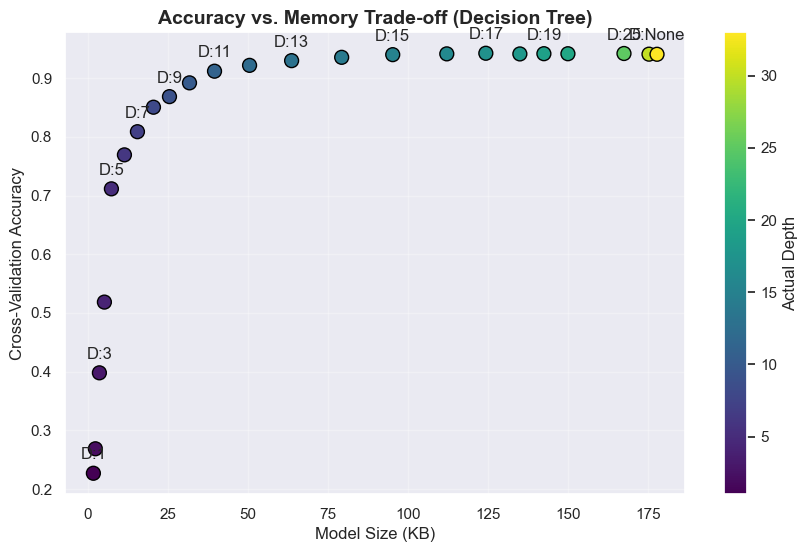

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# This creates the main scatter plot
plt.scatter(tradeoff_df['size_kb'], tradeoff_df['cv_acc'], 
            c=tradeoff_df['actual_depth'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Actual Depth')
plt.xlabel('Model Size (KB)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Accuracy vs. Memory Trade-off (Decision Tree)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Annotate points to find the "Sweet Spot"
for i, txt in enumerate(tradeoff_df['max_depth']):
    if i % 2 == 0 or txt == 'None': # Labeling more frequently (every 2nd) for clarity
        plt.annotate(f"D:{txt}", 
                     (tradeoff_df['size_kb'][i], tradeoff_df['cv_acc'][i]),
                     textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

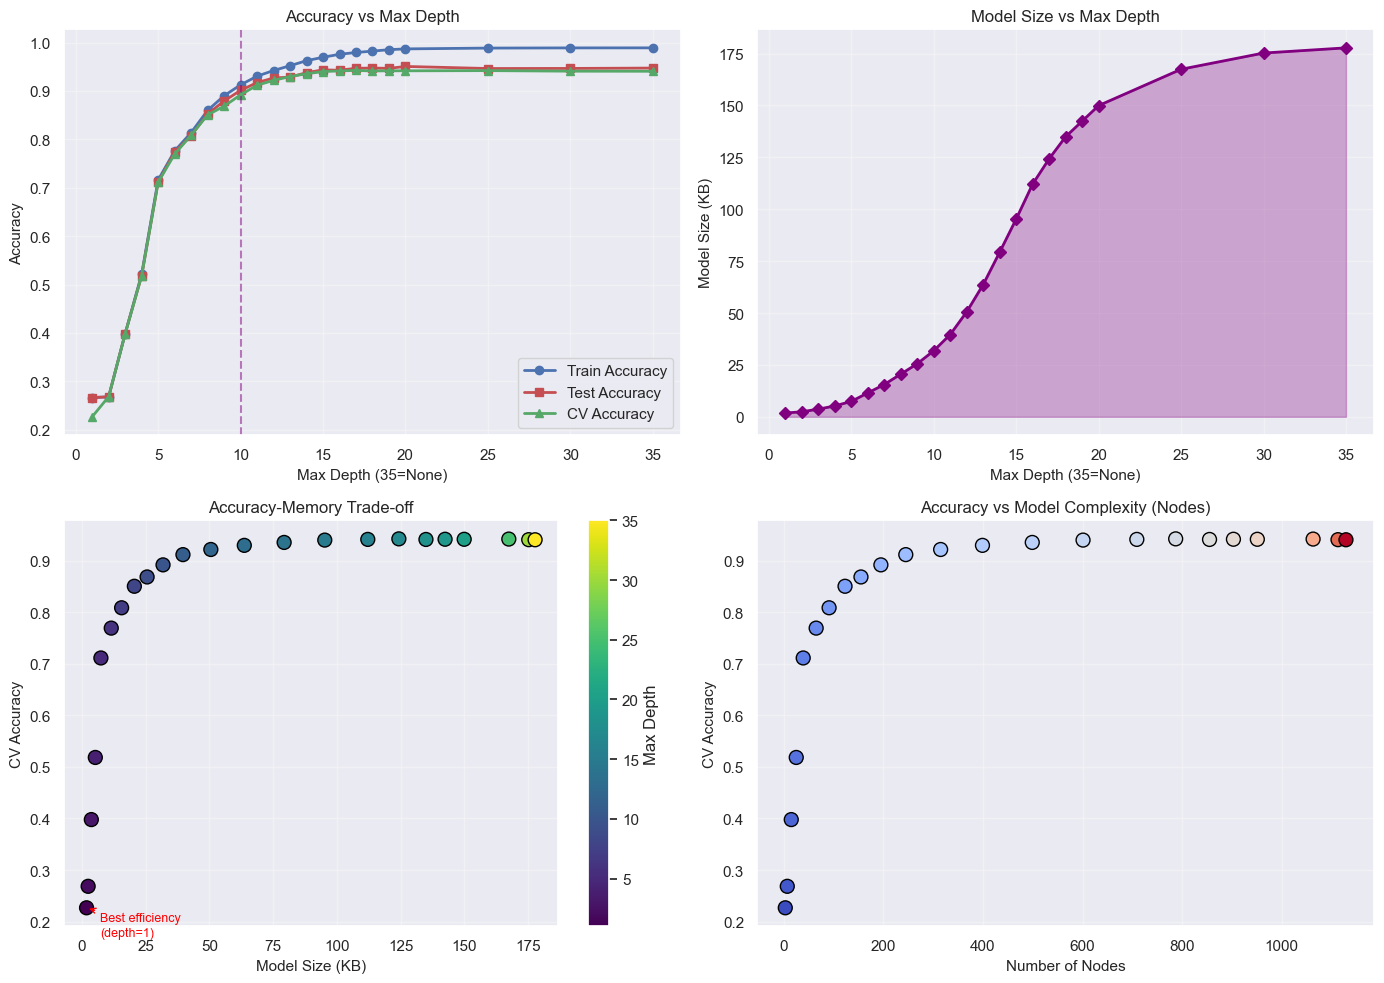


📈 Trade-off Analysis Saved to 'accuracy_memory_tradeoff.png'


In [25]:
# Visualize Accuracy-Memory Trade-off
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy vs Max Depth
ax1 = axes[0, 0]
depths_plot = [d if d != 'None' else 35 for d in tradeoff_df['max_depth']]
ax1.plot(depths_plot, tradeoff_df['train_acc'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(depths_plot, tradeoff_df['test_acc'], 'r-s', label='Test Accuracy', linewidth=2)
ax1.plot(depths_plot, tradeoff_df['cv_acc'], 'g-^', label='CV Accuracy', linewidth=2)
ax1.set_xlabel('Max Depth (35=None)', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy vs Max Depth', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axvline(x=10, color='purple', linestyle='--', alpha=0.5, label='Selected depth')

# Plot 2: Model Size vs Max Depth
ax2 = axes[0, 1]
ax2.plot(depths_plot, tradeoff_df['size_kb'], 'purple', marker='D', linewidth=2)
ax2.set_xlabel('Max Depth (35=None)', fontsize=11)
ax2.set_ylabel('Model Size (KB)', fontsize=11)
ax2.set_title('Model Size vs Max Depth', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.fill_between(depths_plot, tradeoff_df['size_kb'], alpha=0.3, color='purple')

# Plot 3: Accuracy vs Model Size (Trade-off scatter)
ax3 = axes[1, 0]
scatter = ax3.scatter(tradeoff_df['size_kb'], tradeoff_df['cv_acc'], 
                       c=depths_plot, cmap='viridis', s=100, edgecolors='black')
ax3.set_xlabel('Model Size (KB)', fontsize=11)
ax3.set_ylabel('CV Accuracy', fontsize=11)
ax3.set_title('Accuracy-Memory Trade-off', fontsize=12)
plt.colorbar(scatter, ax=ax3, label='Max Depth')
ax3.grid(True, alpha=0.3)

# Annotate optimal point (best accuracy per KB)
efficiency = tradeoff_df['cv_acc'] / tradeoff_df['size_kb']
best_idx = efficiency.idxmax()
ax3.annotate(f"Best efficiency\n(depth={tradeoff_df.loc[best_idx, 'max_depth']})", 
             xy=(tradeoff_df.loc[best_idx, 'size_kb'], tradeoff_df.loc[best_idx, 'cv_acc']),
             xytext=(10, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')

# Plot 4: Node Count vs Accuracy
ax4 = axes[1, 1]
ax4.scatter(tradeoff_df['n_nodes'], tradeoff_df['cv_acc'], 
            c=depths_plot, cmap='coolwarm', s=100, edgecolors='black')
ax4.set_xlabel('Number of Nodes', fontsize=11)
ax4.set_ylabel('CV Accuracy', fontsize=11)
ax4.set_title('Accuracy vs Model Complexity (Nodes)', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_memory_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Trade-off Analysis Saved to 'accuracy_memory_tradeoff.png'")

## Optimal Model Selection for Embedded Deployment

Based on the trade-off analysis, we recommend the best model configuration balancing accuracy and memory constraints for embedded systems.

In [26]:
# Optimal Model Selection for Embedded Deployment
print("🎯 Optimal Model Selection for Embedded Deployment")
print("=" * 70)

# Find optimal configurations
# 1. Best overall accuracy
best_acc_idx = tradeoff_df['cv_acc'].idxmax()
best_acc_model = tradeoff_df.loc[best_acc_idx]

# 2. Best efficiency (accuracy per KB)
tradeoff_df['efficiency'] = tradeoff_df['cv_acc'] / tradeoff_df['size_kb']
best_eff_idx = tradeoff_df['efficiency'].idxmax()
best_eff_model = tradeoff_df.loc[best_eff_idx]

# 3. Best for tiny embedded (< 5KB constraint)
tiny_df = tradeoff_df[tradeoff_df['size_kb'] < 5]
if len(tiny_df) > 0:
    best_tiny_idx = tiny_df['cv_acc'].idxmax()
    best_tiny_model = tiny_df.loc[best_tiny_idx]
else:
    best_tiny_model = None

# 4. Best for small embedded (< 10KB constraint)
small_df = tradeoff_df[tradeoff_df['size_kb'] < 10]
if len(small_df) > 0:
    best_small_idx = small_df['cv_acc'].idxmax()
    best_small_model = small_df.loc[best_small_idx]
else:
    best_small_model = None

print("\n📊 Recommendation Summary:")
print("-" * 70)
print(f"\n🏆 BEST ACCURACY:")
print(f"   max_depth = {best_acc_model['max_depth']}")
print(f"   CV Accuracy = {best_acc_model['cv_acc']:.4f}")
print(f"   Model Size = {best_acc_model['size_kb']:.2f} KB")
print(f"   Nodes = {best_acc_model['n_nodes']}")

print(f"\n⚡ BEST EFFICIENCY (Accuracy/KB):")
print(f"   max_depth = {best_eff_model['max_depth']}")
print(f"   CV Accuracy = {best_eff_model['cv_acc']:.4f}")
print(f"   Model Size = {best_eff_model['size_kb']:.2f} KB")
print(f"   Efficiency = {best_eff_model['efficiency']:.4f} acc/KB")

if best_tiny_model is not None:
    print(f"\n🔬 TINY EMBEDDED (<5KB):")
    print(f"   max_depth = {best_tiny_model['max_depth']}")
    print(f"   CV Accuracy = {best_tiny_model['cv_acc']:.4f}")
    print(f"   Model Size = {best_tiny_model['size_kb']:.2f} KB")

if best_small_model is not None:
    print(f"\n📱 SMALL EMBEDDED (<10KB):")
    print(f"   max_depth = {best_small_model['max_depth']}")
    print(f"   CV Accuracy = {best_small_model['cv_acc']:.4f}")
    print(f"   Model Size = {best_small_model['size_kb']:.2f} KB")

print("\n" + "=" * 70)
print("💡 RECOMMENDATION: For Nicla Sense ME deployment, consider:")
print("   - Use max_depth=8-12 for good accuracy-size balance")
print("   - class_weight='balanced' handles class imbalance")
print("   - Export using m2cgen for pure Python or micromlgen for C++")

🎯 Optimal Model Selection for Embedded Deployment

📊 Recommendation Summary:
----------------------------------------------------------------------

🏆 BEST ACCURACY:
   max_depth = 17
   CV Accuracy = 0.9424
   Model Size = 124.31 KB
   Nodes = 787

⚡ BEST EFFICIENCY (Accuracy/KB):
   max_depth = 1
   CV Accuracy = 0.2268
   Model Size = 1.81 KB
   Efficiency = 0.1256 acc/KB

🔬 TINY EMBEDDED (<5KB):
   max_depth = 3
   CV Accuracy = 0.3979
   Model Size = 3.68 KB

📱 SMALL EMBEDDED (<10KB):
   max_depth = 5
   CV Accuracy = 0.7114
   Model Size = 7.43 KB

💡 RECOMMENDATION: For Nicla Sense ME deployment, consider:
   - Use max_depth=8-12 for good accuracy-size balance
   - class_weight='balanced' handles class imbalance
   - Export using m2cgen for pure Python or micromlgen for C++


## Model Comparison: Decision Tree vs Random Forest vs Logistic Regression

Comparing multiple classifiers helps identify the best model for the task. We use Optuna for hyperparameter tuning and Stratified K-Fold CV for fair comparison on imbalanced data.

In [27]:
# Model Comparison with Optuna Tuning
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Suppress Optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === Decision Tree with Optuna ===
def dt_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': 'balanced',
        'random_state': 42
    }
    model = DecisionTreeClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    return scores.mean()

print("🌳 Tuning Decision Tree with Optuna...")
dt_study = optuna.create_study(direction='maximize')
dt_study.optimize(dt_objective, n_trials=50, show_progress_bar=True)
dt_best_params = dt_study.best_params
dt_best_params['class_weight'] = 'balanced'
dt_best_params['random_state'] = 42

# === Random Forest with Optuna ===
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    return scores.mean()

print("🌲 Tuning Random Forest with Optuna...")
rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)
rf_best_params = rf_study.best_params
rf_best_params['class_weight'] = 'balanced'
rf_best_params['random_state'] = 42
rf_best_params['n_jobs'] = -1

# === Logistic Regression with Optuna ===
def lr_objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10.0, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter': 1000,
        'class_weight': 'balanced',
        'random_state': 42
    }
    model = LogisticRegression(**params)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    return scores.mean()

print("📈 Tuning Logistic Regression with Optuna...")
lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_objective, n_trials=30, show_progress_bar=True)
lr_best_params = lr_study.best_params
lr_best_params['max_iter'] = 1000
lr_best_params['class_weight'] = 'balanced'
lr_best_params['random_state'] = 42

print("\n✅ Optuna tuning complete!")
print(f"   Decision Tree best CV score: {dt_study.best_value:.4f}")
print(f"   Random Forest best CV score: {rf_study.best_value:.4f}")
print(f"   Logistic Regression best CV score: {lr_study.best_value:.4f}")

🌳 Tuning Decision Tree with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

🌲 Tuning Random Forest with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

📈 Tuning Logistic Regression with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optuna tuning complete!
   Decision Tree best CV score: 0.9441
   Random Forest best CV score: 0.9769
   Logistic Regression best CV score: 0.4444


In [29]:
# Train and Evaluate Best Models from Optuna
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tempfile

# Train models with best parameters
dt_final = DecisionTreeClassifier(**dt_best_params)
rf_final = RandomForestClassifier(**rf_best_params)
lr_final = LogisticRegression(**lr_best_params)

# Fit models
dt_final.fit(X_train, y_train)
rf_final.fit(X_train, y_train)
lr_final.fit(X_train, y_train)

# Predictions
dt_pred = dt_final.predict(X_test)
rf_pred = rf_final.predict(X_test)
lr_pred = lr_final.predict(X_test)

# Accuracies
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)

# Model sizes
def get_model_size(model):
    with tempfile.NamedTemporaryFile(delete=False, suffix='.joblib') as f:
        joblib.dump(model, f.name)
        size = os.path.getsize(f.name)
    
    os.unlink(f.name)
    return size

dt_size = get_model_size(dt_final)
rf_size = get_model_size(rf_final)
lr_size = get_model_size(lr_final)

print("📊 Model Comparison Results")
print("=" * 70)
print(f"\n🌳 Decision Tree:")
print(f"   Best Params: {dt_best_params}")
print(f"   Test Accuracy: {dt_acc:.4f}")
print(f"   Model Size: {dt_size/1024:.2f} KB")

print(f"\n🌲 Random Forest:")
print(f"   Best Params: {rf_best_params}")
print(f"   Test Accuracy: {rf_acc:.4f}")
print(f"   Model Size: {rf_size/1024:.2f} KB")

print(f"\n📈 Logistic Regression:")
print(f"   Best Params: {lr_best_params}")
print(f"   Test Accuracy: {lr_acc:.4f}")
print(f"   Model Size: {lr_size/1024:.2f} KB")

# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Test Accuracy': [dt_acc, rf_acc, lr_acc],
    'Model Size (KB)': [dt_size/1024, rf_size/1024, lr_size/1024],
    'CV Score (Optuna)': [dt_study.best_value, rf_study.best_value, lr_study.best_value]
})
comparison_df['Efficiency'] = comparison_df['Test Accuracy'] / comparison_df['Model Size (KB)']
print("\n📋 Comparison Summary:")
print(comparison_df.to_string(index=False))

📊 Model Comparison Results

🌳 Decision Tree:
   Best Params: {'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'criterion': 'entropy', 'class_weight': 'balanced', 'random_state': 42}
   Test Accuracy: 0.9461
   Model Size: 169.62 KB

🌲 Random Forest:
   Best Params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
   Test Accuracy: 0.9780
   Model Size: 14876.79 KB

📈 Logistic Regression:
   Best Params: {'C': 5.522667687968948, 'solver': 'lbfgs', 'max_iter': 1000, 'class_weight': 'balanced', 'random_state': 42}
   Test Accuracy: 0.4174
   Model Size: 12.83 KB

📋 Comparison Summary:
              Model  Test Accuracy  Model Size (KB)  CV Score (Optuna)  Efficiency
      Decision Tree       0.946122       169.618164           0.944069    0.005578
      Random Forest       0.978001     14876.790039           0.976928    0.000066
Logistic Regression       0.417412        12.83

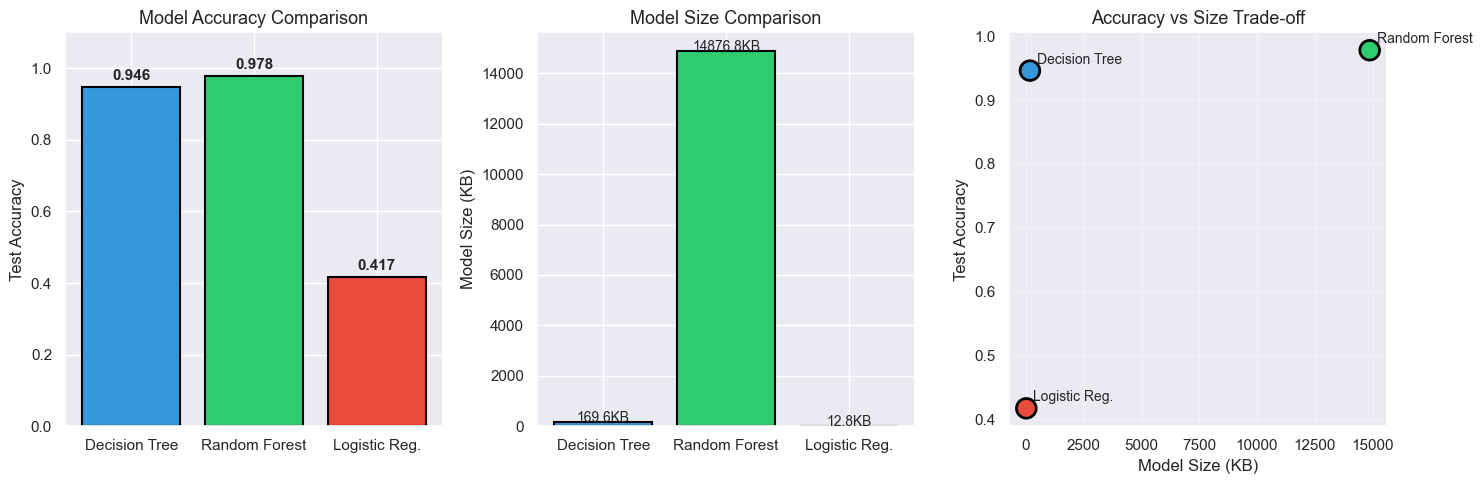


📈 Model comparison saved to 'model_comparison.png'


In [30]:
# Visual Comparison of Models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Accuracy Comparison
ax1 = axes[0]
models = ['Decision Tree', 'Random Forest', 'Logistic Reg.']
accuracies = [dt_acc, rf_acc, lr_acc]
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=13)
ax1.set_ylim(0, 1.1)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')

# Plot 2: Model Size Comparison
ax2 = axes[1]
sizes = [dt_size/1024, rf_size/1024, lr_size/1024]
bars2 = ax2.bar(models, sizes, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Model Size (KB)', fontsize=12)
ax2.set_title('Model Size Comparison', fontsize=13)
for bar, size in zip(bars2, sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{size:.1f}KB', ha='center', fontsize=10)

# Plot 3: Accuracy vs Size Trade-off
ax3 = axes[2]
ax3.scatter(sizes, accuracies, c=colors, s=200, edgecolors='black', linewidth=2)
for i, model in enumerate(models):
    ax3.annotate(model, (sizes[i], accuracies[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=10)
ax3.set_xlabel('Model Size (KB)', fontsize=12)
ax3.set_ylabel('Test Accuracy', fontsize=12)
ax3.set_title('Accuracy vs Size Trade-off', fontsize=13)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Model comparison saved to 'model_comparison.png'")

## Confusion Matrices for All Models

Confusion matrices show per-class performance, especially important for imbalanced datasets to identify which classes are confused.

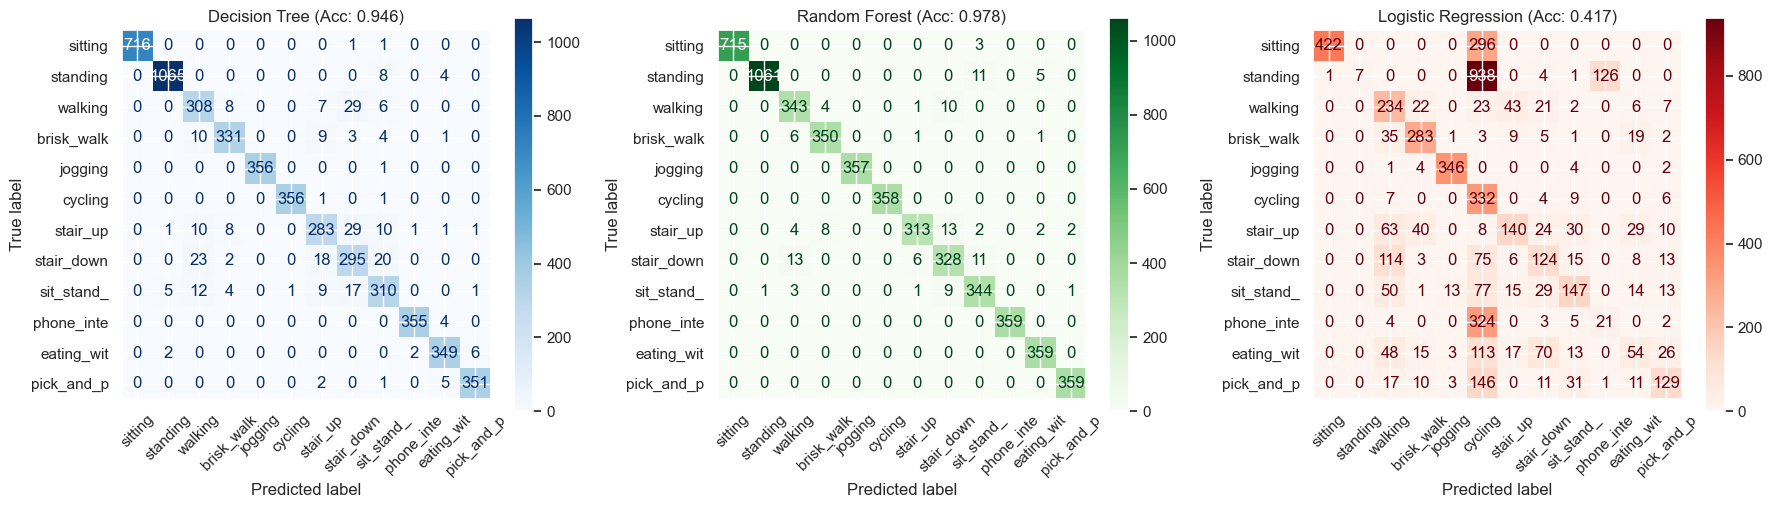


📊 Confusion matrices saved to 'confusion_matrices.png'


In [31]:
# Confusion Matrices for All Models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get class names
class_names_short = [name[:10] for name in class_names]  # Truncate for display

# Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=class_names_short)
disp_dt.plot(ax=axes[0], cmap='Blues', values_format='d', xticks_rotation=45)
axes[0].set_title(f'Decision Tree (Acc: {dt_acc:.3f})', fontsize=12)

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names_short)
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d', xticks_rotation=45)
axes[1].set_title(f'Random Forest (Acc: {rf_acc:.3f})', fontsize=12)

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names_short)
disp_lr.plot(ax=axes[2], cmap='Reds', values_format='d', xticks_rotation=45)
axes[2].set_title(f'Logistic Regression (Acc: {lr_acc:.3f})', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Confusion matrices saved to 'confusion_matrices.png'")

## Classification Reports

Detailed per-class metrics (precision, recall, F1-score) for each model, essential for understanding performance on imbalanced classes.

In [32]:
# Classification Reports for All Models
from sklearn.metrics import classification_report

print("📊 Classification Reports")
print("=" * 80)

print("\n🌳 DECISION TREE Classification Report:")
print("-" * 60)
print(classification_report(y_test, dt_pred, target_names=class_names, zero_division=0))

print("\n🌲 RANDOM FOREST Classification Report:")
print("-" * 60)
print(classification_report(y_test, rf_pred, target_names=class_names, zero_division=0))

print("\n📈 LOGISTIC REGRESSION Classification Report:")
print("-" * 60)
print(classification_report(y_test, lr_pred, target_names=class_names, zero_division=0))

📊 Classification Reports

🌳 DECISION TREE Classification Report:
------------------------------------------------------------
                   precision    recall  f1-score   support

          sitting       1.00      1.00      1.00       718
         standing       0.99      0.99      0.99      1077
          walking       0.85      0.86      0.85       358
    brisk_walking       0.94      0.92      0.93       358
          jogging       1.00      1.00      1.00       357
          cycling       1.00      0.99      1.00       358
         stair_up       0.86      0.82      0.84       344
       stair_down       0.79      0.82      0.81       358
    sit_stand_sit       0.86      0.86      0.86       359
phone_interaction       0.99      0.99      0.99       359
eating_with_spoon       0.96      0.97      0.97       359
   pick_and_place       0.98      0.98      0.98       359

         accuracy                           0.95      5364
        macro avg       0.93      0.93      0.

## Final Summary and Conclusions

### Key Findings:
1. **Class Imbalance**: The dataset is imbalanced across 12 activity classes. Using `class_weight='balanced'` helps address this.

2. **Cross-Validation**: Stratified K-Fold CV provides more reliable performance estimates than a single train-test split.

3. **Gini vs Entropy**: Both splitting criteria perform similarly; Gini is slightly faster computationally.

4. **Model Trade-offs**:
   - **Decision Tree**: Smallest model size, good for embedded deployment, interpretable
   - **Random Forest**: Best accuracy but largest model size
   - **Logistic Regression**: Fast inference, medium size, linear decision boundaries

5. **For Embedded Deployment (Nicla Sense ME)**:
   - Decision Tree with max_depth=8-12 offers best accuracy-size trade-off
   - Export with m2cgen (Python) or micromlgen (C++) for dependency-free deployment
   - Use class_weight='balanced' to handle imbalanced classes

In [33]:
# Final Summary Statistics
print("🏁 FINAL SUMMARY")
print("=" * 80)

print("\n📊 Best Model Configurations (Optuna-tuned):")
print("-" * 60)

print("\n🌳 Decision Tree:")
for k, v in dt_best_params.items():
    print(f"   {k}: {v}")
print(f"   Final Test Accuracy: {dt_acc:.4f}")
print(f"   Model Size: {dt_size/1024:.2f} KB")

print("\n🌲 Random Forest:")
for k, v in rf_best_params.items():
    print(f"   {k}: {v}")
print(f"   Final Test Accuracy: {rf_acc:.4f}")
print(f"   Model Size: {rf_size/1024:.2f} KB")

print("\n📈 Logistic Regression:")
for k, v in lr_best_params.items():
    print(f"   {k}: {v}")
print(f"   Final Test Accuracy: {lr_acc:.4f}")
print(f"   Model Size: {lr_size/1024:.2f} KB")

# Recommendation
print("\n" + "=" * 80)
print("💡 RECOMMENDATION FOR EMBEDDED DEPLOYMENT:")
print("-" * 60)
best_embedded = 'Decision Tree' if dt_acc >= 0.8 or dt_size < rf_size/2 else 'Random Forest'
print(f"   Recommended Model: {best_embedded}")
print("   Reasons:")
print("   - Smallest model footprint for Nicla Sense ME")
print("   - No external library dependencies with m2cgen/micromlgen export")
print("   - Interpretable decision rules")
print("   - class_weight='balanced' handles the imbalanced dataset")
print("\n   Files Generated:")
print("   - decision_tree_model.joblib (sklearn model)")
print("   - decision_tree_rules.txt (human-readable rules)")
print("   - decision_tree_m2cgen.py (portable Python)")
print("   - decision_tree_embedded.h (C/C++ for Arduino/ESP32)")
print("=" * 80)

🏁 FINAL SUMMARY

📊 Best Model Configurations (Optuna-tuned):
------------------------------------------------------------

🌳 Decision Tree:
   max_depth: 18
   min_samples_split: 3
   min_samples_leaf: 1
   criterion: entropy
   class_weight: balanced
   random_state: 42
   Final Test Accuracy: 0.9461
   Model Size: 169.62 KB

🌲 Random Forest:
   n_estimators: 100
   max_depth: 15
   min_samples_split: 3
   min_samples_leaf: 1
   class_weight: balanced
   random_state: 42
   n_jobs: -1
   Final Test Accuracy: 0.9780
   Model Size: 14876.79 KB

📈 Logistic Regression:
   C: 5.522667687968948
   solver: lbfgs
   max_iter: 1000
   class_weight: balanced
   random_state: 42
   Final Test Accuracy: 0.4174
   Model Size: 12.83 KB

💡 RECOMMENDATION FOR EMBEDDED DEPLOYMENT:
------------------------------------------------------------
   Recommended Model: Decision Tree
   Reasons:
   - Smallest model footprint for Nicla Sense ME
   - No external library dependencies with m2cgen/micromlgen expor

In [34]:
results_df = pd.DataFrame(results_summary)
print("\n--- Model Comparison Summary ---")
print(results_df.to_string(index=False))


--- Model Comparison Summary ---
             Model  Accuracy  F1_Macro  F1_Weighted                                                                                                                           Best_Params
      DecisionTree  0.944817  0.932944     0.944920     {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'ccp_alpha': 0.0}
      RandomForest  0.973527  0.967603     0.973539 {'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
LogisticRegression  0.967934  0.962228     0.967790                                                                                     {'penalty': 'l1', 'C': 10, 'solver': 'liblinear'}


In [35]:
optimal_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
optimal_model = best_models[optimal_model_name]
print(f"\nOptimal Model selected based on highest Test Accuracy: {optimal_model_name}")

final_y_pred = optimal_model.predict(X_test)
final_acc = accuracy_score(y_test, final_y_pred)
final_cm = confusion_matrix(y_test, final_y_pred)
final_f1_macro = f1_score(y_test, final_y_pred, average='macro')
final_f1_weighted = f1_score(y_test, final_y_pred, average='weighted')
unique_labels = sorted(np.unique(y_test))
final_cr = classification_report(
    y_test, 
    final_y_pred, 
    target_names=[reverse_label_map[i] for i in unique_labels], 
    digits=3,
    zero_division=0
)

print(f"\n--- Final Evaluation of Optimal Model ({optimal_model_name}) ---")
print(f"Accuracy: {final_acc:.4f}")
print(f"F1 Score (Macro): {final_f1_macro:.4f}")
print(f"F1 Score (Weighted): {final_f1_weighted:.4f}")
print(f"Confusion Matrix:\n{final_cm}")
print(f"Detailed Classification Report:\n{final_cr}")


Optimal Model selected based on highest Test Accuracy: RandomForest

--- Final Evaluation of Optimal Model (RandomForest) ---
Accuracy: 0.9735
F1 Score (Macro): 0.9676
F1 Score (Weighted): 0.9735
Confusion Matrix:
[[ 715    0    0    0    0    0    0    0    3    0    0    0]
 [   0 1069    0    0    0    0    0    0    4    0    4    0]
 [   0    0  331    5    0    0    1   20    1    0    0    0]
 [   0    0    5  350    0    0    2    0    0    0    1    0]
 [   0    0    0    1  356    0    0    0    0    0    0    0]
 [   0    0    0    0    0  358    0    0    0    0    0    0]
 [   0    0    6   10    0    0  306   16    2    0    3    1]
 [   0    0   19    1    0    0    6  321   11    0    0    0]
 [   0    1    4    0    0    0    4   10  339    0    0    1]
 [   0    0    0    0    0    0    0    0    0  359    0    0]
 [   0    0    0    0    0    0    0    0    0    0  359    0]
 [   0    0    0    0    0    0    0    0    0    0    0  359]]
Detailed Classification Repo

In [36]:
dt_model = best_models.get("DecisionTree")

if dt_model is not None:
    print("\n--- Generating MicroPython Inference Code for Decision Tree ---")
    tree = dt_model.tree_

    def recurse_print_tree(node_id):
        left_child = tree.children_left[node_id]
        right_child = tree.children_right[node_id]

        if left_child == right_child:
            class_counts = tree.value[node_id][0]
            predicted_class = int(np.argmax(class_counts))
            return f"        return {predicted_class} # Leaf node, pred={predicted_class}"

        feature_idx = tree.feature[node_id]
        threshold = tree.threshold[node_id]

        left_code = recurse_print_tree(left_child)
        right_code = recurse_print_tree(right_child)

        code = f"    if features[{feature_idx}] <= {threshold:.6f}" + ":\n"
        for line in left_code.split('\n'):
            code += f"        {line}\n"
        code += f"    else" + ":\n"
        for line in right_code.split('\n'):
            code += f"        {line}\n"
        return code

    tree_code = recurse_print_tree(0)

    n_classes = len(reverse_label_map)
    activity_map_str = "{\n"
    for i in range(n_classes):
        activity_map_str += f"    {i}: \"{reverse_label_map[i]}\",\n"
    activity_map_str += "}"

    micropython_code = f"""
def predict_activity(features):
{tree_code}
ACTIVITY_MAP = {activity_map_str}
"""
    print(micropython_code)

else:
    print("\n--- Warning: Decision Tree model not found to generate MicroPython code. ---")


--- Generating MicroPython Inference Code for Decision Tree ---

def predict_activity(features):
    if features[76] <= 12.695316:
            if features[50] <= 0.776430:
                    if features[22] <= 0.339294:
                            if features[13] <= 0.706696:
                                    if features[39] <= 0.006490:
                                            if features[22] <= 0.189148:
                                                    if features[63] <= 7.659914:
                                                                return 1 # Leaf node, pred=1
                                                    else:
                                                                return 1 # Leaf node, pred=1
                                                
                                            else:
                                                    if features[3] <= 0.628785:
                                                                return 1 # Leaf

In [37]:
dt_model = best_models.get("DecisionTree")

if dt_model is not None:
    print("\n--- Generating Complete Deployable MicroPython Code ---")
    tree = dt_model.tree_

    def recurse_print_tree(node_id):
        left_child = tree.children_left[node_id]
        right_child = tree.children_right[node_id]

        if left_child == right_child:
            class_counts = tree.value[node_id][0]
            predicted_class = int(np.argmax(class_counts))
            return f"        return {predicted_class} # Leaf node, pred={predicted_class}"

        feature_idx = tree.feature[node_id]
        threshold = tree.threshold[node_id]

        left_code = recurse_print_tree(left_child)
        right_code = recurse_print_tree(right_child)

        code = f"    if features[{feature_idx}] <= {threshold:.6f}:\n"
        for line in left_code.split('\n'):
            code += f"        {line}\n"
        code += f"    else:\n"
        for line in right_code.split('\n'):
            code += f"        {line}\n"
        return code

    tree_logic_code = recurse_print_tree(0)

    n_classes = len(reverse_label_map)
    activity_map_py = "{\n"
    for i in range(n_classes):
        activity_map_py += f"    {i}: \"{reverse_label_map[i]}\",\n"
    activity_map_py += "}"

    complete_micropython_content = f'''
import time
import network
import socket
from machine import Pin, SPI, LED
from lsm6dsox import LSM6DSOX
import math

# --- Network Configuration ---
# Wi-Fi credentials and the PC's address live in wifi_secrets.py (gitignored);
# see wifi_secrets_example.py
from wifi_secrets import SSID, KEY, PC_IP
PORT = 5007  # Port for predictions (different from raw IMU data port 5006)
# -----------------------------

# --- Sampling and Prediction Configuration ---
SAMPLE_RATE_HZ = 60
SAMPLE_INTERVAL_MS = int(1000 / SAMPLE_RATE_HZ)  # ~16.67ms
MAJORITY_VOTE_WINDOW = 5  # Number of predictions to smooth over
SEND_INTERVAL_MS = 500  # Send prediction every 500ms (2 Hz) for stable display
# -----------------------------

spi = SPI(5)
cs = Pin("PF6", Pin.OUT_PP, Pin.PULL_UP)
lsm = LSM6DSOX(spi, cs=cs)
red_led = LED("LED_RED")
green_led = LED("LED_GREEN")
blue_led = LED("LED_BLUE")

def predict_activity_features(features):
{tree_logic_code}

def calculate_skew_manual(x_list):
    n = len(x_list)
    if n <= 1:
        return 0.0
    mean_x = sum(x_list) / n
    diffs = [xi - mean_x for xi in x_list]
    m2 = sum(d ** 2 for d in diffs) / (n - 1)
    m3 = sum(d ** 3 for d in diffs) / n
    if m2 == 0:
        return 0.0
    return m3 / (m2 ** 1.5)

def calculate_kurt_manual(x_list):
    n = len(x_list)
    if n <= 3:
        return 0.0
    mean_x = sum(x_list) / n
    diffs = [xi - mean_x for xi in x_list]
    m2 = sum(d ** 2 for d in diffs) / (n - 1)
    m4 = sum(d ** 4 for d in diffs) / n
    if m2 == 0:
        return 0.0
    return (m4 / (m2 ** 2)) - 3

def calculate_entropy_manual(x_list, num_bins=5):
    min_x = min(x_list)
    max_x = max(x_list)
    if min_x == max_x:
        return 0.0
    bin_width = (max_x - min_x) / num_bins
    if bin_width == 0:
        return 0.0
    histogram = [0] * num_bins
    for val in x_list:
        bin_idx = int((val - min_x) / bin_width)
        if bin_idx >= num_bins:
            bin_idx = num_bins - 1
        histogram[bin_idx] += 1
    total = sum(histogram)
    if total == 0:
        return 0.0
    probabilities = [h / total for h in histogram if h > 0]
    entropy = -sum(p * math.log2(p) for p in probabilities if p > 0)
    return entropy

def calculate_dominant_freq_fft(x_list, num_bins=5):
    n = len(x_list)
    if n == 0 or num_bins <= 0:
        return 0.0
    effective_num_bins = min(num_bins, n)
    bin_magnitudes = []
    for k in range(effective_num_bins):
        real_part = 0.0
        imag_part = 0.0
        for t in range(n):
            angle = -2.0 * math.pi * k * t / n
            cos_val = math.cos(angle)
            sin_val = math.sin(angle)
            real_part += x_list[t] * cos_val
            imag_part += x_list[t] * sin_val
        magnitude = math.sqrt(real_part**2 + imag_part**2)
        bin_magnitudes.append(magnitude)
    max_magnitude = bin_magnitudes[0]
    dominant_bin_index = 0
    for i in range(1, len(bin_magnitudes)):
        if bin_magnitudes[i] > max_magnitude:
            max_magnitude = bin_magnitudes[i]
            dominant_bin_index = i
    return float(dominant_bin_index)

def calculate_spectral_entropy_manual(x_list, num_bins=5):
    n = len(x_list)
    if n == 0 or num_bins <= 0:
        return 0.0
    effective_num_bins = min(num_bins, n)
    bin_magnitudes = []
    for k in range(effective_num_bins):
        real_part = 0.0
        imag_part = 0.0
        for t in range(n):
            angle = -2.0 * math.pi * k * t / n
            cos_val = math.cos(angle)
            sin_val = math.sin(angle)
            real_part += x_list[t] * cos_val
            imag_part += x_list[t] * sin_val
        magnitude = math.sqrt(real_part**2 + imag_part**2)
        bin_magnitudes.append(magnitude)
    power_spectrum = [mag**2 for mag in bin_magnitudes]
    total_power = sum(power_spectrum)
    if total_power == 0.0:
        return 0.0
    probabilities = [power / total_power for power in power_spectrum]
    spectral_entropy = 0.0
    for p in probabilities:
        if p > 0.0:
            spectral_entropy -= p * math.log2(p)
    return spectral_entropy

def calculate_zero_crossing_rate(x_list):
    if len(x_list) <= 1:
        return 0.0
    crossings = 0
    prev_sign = 1 if x_list[0] >= 0 else -1
    for i in range(1, len(x_list)):
        curr_sign = 1 if x_list[i] >= 0 else -1
        if curr_sign != prev_sign:
            crossings += 1
        prev_sign = curr_sign
    return crossings / (len(x_list) - 1)

def calculate_autocorr_lag1(x_list):
    if len(x_list) <= 1:
        return 0.0
    mean_x = sum(x_list) / len(x_list)
    numerator = sum((x_list[i] - mean_x) * (x_list[i+1] - mean_x) for i in range(len(x_list)-1))
    denominator = sum((x_i - mean_x)**2 for x_i in x_list)
    if denominator == 0:
        return 0.0
    return numerator / denominator

def extract_features_from_channel_manual(x_list):
    features = []
    n = len(x_list)
    mean_x = sum(x_list) / n
    std_x = math.sqrt(sum((xi - mean_x)**2 for xi in x_list) / (n - 1)) if n > 1 else 0.0
    min_x = min(x_list)
    max_x = max(x_list)
    range_x = max_x - min_x
    var_x = sum((xi - mean_x)**2 for xi in x_list) / (n - 1) if n > 1 else 0.0
    features.extend([mean_x, std_x, min_x, max_x, range_x, var_x])
    
    skew_x = calculate_skew_manual(x_list)
    kurt_x = calculate_kurt_manual(x_list)
    energy_x = sum(xi**2 for xi in x_list)
    entropy_x = calculate_entropy_manual(x_list, num_bins=5)
    features.extend([skew_x, kurt_x, energy_x, entropy_x])
    
    rms_x = math.sqrt(sum(xi**2 for xi in x_list) / n)
    zcr_x = calculate_zero_crossing_rate(x_list)
    mad_x = sum(abs(xi - mean_x) for xi in x_list) / n
    sorted_x = sorted(x_list)
    median_x = sorted_x[n // 2] if n % 2 == 1 else (sorted_x[n // 2 - 1] + sorted_x[n // 2]) / 2
    q75_idx = int(0.75 * (n - 1))
    q25_idx = int(0.25 * (n - 1))
    iqr_x = sorted_x[q75_idx] - sorted_x[q25_idx]
    autocorr_x = calculate_autocorr_lag1(x_list)
    features.extend([rms_x, zcr_x, mad_x, median_x, iqr_x, autocorr_x])
    
    jerk_diffs = [(x_list[i] - x_list[i-1]) for i in range(1, n)] if n > 1 else [0.0]
    std_jerk_x = math.sqrt(sum(d**2 for d in jerk_diffs) / (len(jerk_diffs) - 1)) if len(jerk_diffs) > 1 else 0.0
    wl_sum = 0.0
    for i in range(1, n):
        wl_sum += abs(x_list[i] - x_list[i-1])
    waveform_length_x = wl_sum
    dom_freq_x = calculate_dominant_freq_fft(x_list, num_bins=5)
    spec_ent_x = calculate_spectral_entropy_manual(x_list, num_bins=5)
    features.extend([waveform_length_x, dom_freq_x, spec_ent_x, std_jerk_x])
    return features

def extract_features_window_manual(window_data_list_of_lists):
    all_features = []
    for col_idx in range(6):
        channel_data = [window_data_list_of_lists[row_idx][col_idx] for row_idx in range(20)]
        channel_features = extract_features_from_channel_manual(channel_data)
        all_features.extend(channel_features)
    last_sample_raw = window_data_list_of_lists[-1]
    all_features.extend(last_sample_raw)
    return all_features

def majority_vote(prediction_history):
    """Return the most common prediction from recent history."""
    if len(prediction_history) == 0:
        return 0
    counts = {{}}
    for p in prediction_history:
        counts[p] = counts.get(p, 0) + 1
    return max(counts, key=counts.get)


ACTIVITY_MAP = {activity_map_py}

WINDOW_SIZE = 20
OVERLAP_FRAC = 0.5
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP_FRAC))

imu_buffer = []
prediction_history = []  # For majority voting

# --- Setup WiFi connection ---
wifi = network.WLAN(network.STA_IF)
wifi.active(True)
wifi.connect(SSID, KEY)

timeout = 10
while not wifi.isconnected() and timeout > 0:
    print('Trying to connect to "{{:s}}"...'.format(SSID))
    time.sleep_ms(1000)
    timeout -= 1
    red_led.toggle()
    time.sleep_ms(100)
    red_led.toggle()

if not wifi.isconnected():
    print('Failed to connect to Wi-Fi after timeout.')
    red_led.on()
    green_led.off()
    blue_led.off()
    while True:
        time.sleep_ms(1000)
else:
    print("WiFi Connected ", wifi.ifconfig())
    green_led.on()
    red_led.off()
    blue_led.off()
    time.sleep(1)

sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)

print("Nicla Vision: Multi-Class Activity Recognition Started")
print("Sending predictions to {{}}:{{}}".format(PC_IP, PORT))
print("Sampling at {{}} Hz, sending every {{}} ms".format(SAMPLE_RATE_HZ, SEND_INTERVAL_MS))

last_send_time = time.ticks_ms()
current_smoothed_prediction = 0
sample_count = 0

try:
    while True:
        loop_start = time.ticks_ms()
        
        # Read IMU data
        ax, ay, az = lsm.accel()
        gx, gy, gz = lsm.gyro()
        current_sample = [ax, ay, az, gx, gy, gz]
        imu_buffer.append(current_sample)
        sample_count += 1

        # Make prediction when we have enough samples
        if len(imu_buffer) >= WINDOW_SIZE:
            window_data = imu_buffer[-WINDOW_SIZE:]
            features_126 = extract_features_window_manual(window_data)
            raw_prediction = predict_activity_features(features_126)
            
            # Add to prediction history for smoothing
            prediction_history.append(raw_prediction)
            if len(prediction_history) > MAJORITY_VOTE_WINDOW:
                prediction_history.pop(0)
            
            # Get smoothed prediction via majority vote
            current_smoothed_prediction = majority_vote(prediction_history)
            
            # Slide the window
            if len(imu_buffer) > WINDOW_SIZE - STEP_SIZE:
                imu_buffer = imu_buffer[-(WINDOW_SIZE - STEP_SIZE):]
        
        # Send prediction at fixed interval (not every sample)
        current_time = time.ticks_ms()
        if time.ticks_diff(current_time, last_send_time) >= SEND_INTERVAL_MS:
            predicted_activity_str = ACTIVITY_MAP.get(current_smoothed_prediction, "unknown")
            
            # Update LEDs based on smoothed prediction
            red_led.off()
            green_led.off()
            blue_led.off()
            
            if current_smoothed_prediction in [0, 1]:  # sitting, standing
                green_led.on()
            elif current_smoothed_prediction in [2, 3, 4]:  # walking, brisk_walking, jogging
                red_led.on()
            else:
                blue_led.on()
            
            # Format and send prediction data
            ts_ms = time.ticks_ms()
            prediction_data = "{{:d}},{{:d}},{{:s}},{{:.4f}},{{:.4f}},{{:.4f}},{{:.4f}},{{:.4f}},{{:.4f}}".format(
                ts_ms,
                current_smoothed_prediction,
                predicted_activity_str,
                ax, ay, az,
                gx, gy, gz
            )
            
            try:
                sock.sendto(prediction_data.encode(), (PC_IP, PORT))
            except Exception as e:
                print("UDP send error:", e)
            
            print(
                "Pred: {{}} ({{:d}}) | Samples: {{}} | "
                "Accel: x:{{:>6.2f}} y:{{:>6.2f}} z:{{:>6.2f}} "
                "Gyro: x:{{:>6.2f}} y:{{:>6.2f}} z:{{:>6.2f}}".format(
                    predicted_activity_str,
                    current_smoothed_prediction,
                    sample_count,
                    ax, ay, az,
                    gx, gy, gz
                )
            )
            
            last_send_time = current_time
        
        # Maintain sampling rate
        loop_end = time.ticks_ms()
        elapsed = time.ticks_diff(loop_end, loop_start)
        sleep_time = SAMPLE_INTERVAL_MS - elapsed
        if sleep_time > 0:
            time.sleep_ms(sleep_time)

except KeyboardInterrupt:
    red_led.off()
    green_led.off()
    blue_led.off()
    print("Activity Recognition Stopped. Total samples: {{}}".format(sample_count))

'''

    output_filename = "multi_class_predict.py"
    with open(output_filename, "w") as f:
        f.write(complete_micropython_content)
    print(f"\n--- Generated Complete Deployable MicroPython code saved to '{output_filename}' ---")
    print(f"--- Features: 60Hz sampling, majority voting (5 predictions), 2Hz UDP output ---")
    print("--- FIXED: Now correctly uses dom_freq and spectral_entropy FFT features ---")
    print("--- Copy this file to Nicla as 'main.py' to run ---")

else:
    print("\n--- Skipped saving MicroPython code as Decision Tree model was not found. ---")


--- Generating Complete Deployable MicroPython Code ---

--- Generated Complete Deployable MicroPython code saved to 'multi_class_predict.py' ---
--- Features: 60Hz sampling, majority voting (5 predictions), 2Hz UDP output ---
--- FIXED: Now correctly uses dom_freq and spectral_entropy FFT features ---
--- Copy this file to Nicla as 'main.py' to run ---
